# Exploratory Data Analysis (EDA)  
## ClinVar Conflicting Variant Classification

In [1]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC

df = pd.read_csv('../data/raw/clinvar_conflicting.csv',
                 dtype={'CHROM': str})


/var/folders/tl/5pdn6vld70l0ndj9lvltyvxw0000gn/T/ipykernel_28172/688925404.py:17: DtypeWarning: Columns (38,40) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/raw/clinvar_conflicting.csv',


In [2]:
# Vista general del conjunt de dades
print("Forma")
print(df.shape)

print("Tipus de dades")
df.info()

Forma
(65188, 46)
Tipus de dades
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65188 entries, 0 to 65187
Data columns (total 46 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CHROM               65188 non-null  object 
 1   POS                 65188 non-null  int64  
 2   REF                 65188 non-null  object 
 3   ALT                 65188 non-null  object 
 4   AF_ESP              65188 non-null  float64
 5   AF_EXAC             65188 non-null  float64
 6   AF_TGP              65188 non-null  float64
 7   CLNDISDB            65188 non-null  object 
 8   CLNDISDBINCL        167 non-null    object 
 9   CLNDN               65188 non-null  object 
 10  CLNDNINCL           167 non-null    object 
 11  CLNHGVS             65188 non-null  object 
 12  CLNSIGINCL          167 non-null    object 
 13  CLNVC               65188 non-null  object 
 14  CLNVI               27659 non-null  object 
 15  MC                  

In [3]:
import pandas as pd

pd.set_option("display.max_columns", None)
display(df)


,CHROM,POS,REF,ALT,AF_ESP,AF_EXAC,AF_TGP,CLNDISDB,CLNDISDBINCL,CLNDN,CLNDNINCL,CLNHGVS,CLNSIGINCL,CLNVC,CLNVI,MC,ORIGIN,SSR,CLASS,Allele,Consequence,IMPACT,SYMBOL,Feature_type,Feature,BIOTYPE,EXON,INTRON,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,DISTANCE,STRAND,BAM_EDIT,SIFT,PolyPhen,MOTIF_NAME,MOTIF_POS,HIGH_INF_POS,MOTIF_SCORE_CHANGE,LoFtool,CADD_PHRED,CADD_RAW,BLOSUM62
0,1,1168180,G,C,0.0771,0.10020,0.1066,MedGen:CN169374,NaN,not_specified,NaN,NC_000001.10:g.1168180G>C,NaN,single_nucleotide_variant,UniProtKB_(protein):Q96L58#VAR_059317,SO:0001583|missense_variant,1,NaN,0,C,missense_variant,MODERATE,B3GALT6,Transcript,NM_080605.3,protein_coding,1/1,NaN,552,522,174,E/D,gaG/gaC,NaN,1.0,NaN,tolerated,benign,NaN,NaN,NaN,NaN,NaN,1.053,-0.208682,2.0
1,1,1470752,G,A,0.0000,0.00000,0.0000,"MedGen:C1843891,OMIM:607454,Orphanet:ORPHA9877...",NaN,Spinocerebellar_ataxia_21|not_provided,NaN,NC_000001.10:g.1470752G>A,NaN,single_nucleotide_variant,OMIM_Allelic_Variant:616101.0001|UniProtKB_(pr...,SO:0001583|missense_variant,1,NaN,0,A,missense_variant,MODERATE,TMEM240,Transcript,NM_001114748.1,protein_coding,4/4,NaN,523,509,170,P/L,cCg/cTg,NaN,-1.0,OK,deleterious_low_confidence,benign,NaN,NaN,NaN,NaN,NaN,31.000,6.517838,-3.0
2,1,1737942,A,G,0.0000,0.00001,0.0000,"Human_Phenotype_Ontology:HP:0000486,MedGen:C00...",NaN,Strabismus|Nystagmus|Hypothyroidism|Intellectu...,NaN,NC_000001.10:g.1737942A>G,NaN,single_nucleotide_variant,OMIM_Allelic_Variant:139380.0002|UniProtKB_(pr...,"SO:0001583|missense_variant,SO:0001623|5_prime...",35,NaN,1,G,missense_variant,MODERATE,GNB1,Transcript,NM_002074.4,protein_coding,6/12,NaN,632,239,80,I/T,aTc/aCc,NaN,-1.0,OK,deleterious,probably_damaging,NaN,NaN,NaN,NaN,NaN,28.100,6.061752,-1.0
3,1,2160305,G,A,0.0000,0.00000,0.0000,"MedGen:C1321551,OMIM:182212,SNOMED_CT:83092002...",NaN,Shprintzen-Goldberg_syndrome|not_provided,NaN,NC_000001.10:g.2160305G>A,NaN,single_nucleotide_variant,OMIM_Allelic_Variant:164780.0004|UniProtKB_(pr...,SO:0001583|missense_variant,33,NaN,0,A,missense_variant,MODERATE,SKI,Transcript,XM_005244775.1,protein_coding,1/7,NaN,132,100,34,G/S,Ggc/Agc,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.500,3.114491,NaN
4,1,2160305,G,T,0.0000,0.00000,0.0000,"MedGen:C1321551,OMIM:182212,SNOMED_CT:83092002",NaN,Shprintzen-Goldberg_syndrome,NaN,NC_000001.10:g.2160305G>T,NaN,single_nucleotide_variant,OMIM_Allelic_Variant:164780.0005|UniProtKB_(pr...,SO:0001583|missense_variant,33,NaN,0,T,missense_variant,MODERATE,SKI,Transcript,XM_005244775.1,protein_coding,1/7,NaN,132,100,34,G/C,Ggc/Tgc,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.700,4.766224,-3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65183,X,154158201,T,G,0.0801,0.13923,0.1605,"MedGen:C0019069,OMIM:306700,SNOMED_CT:28293008...",NaN,Hereditary_factor_VIII_deficiency_disease|not_...,NaN,NC_000023.10:g.154158201T>G,NaN,single_nucleotide_variant,"ARUP_Laboratories,_Molecular_Genetics_and_Geno...",SO:0001819|synonymous_variant,1,NaN,0,G,synonymous_variant,LOW,F8,Transcript,NM_000132.3,protein_coding,14/26,NaN,4035,3864,1288,S,tcA/tcC,NaN,-1.0,OK,NaN,NaN,NaN,NaN,NaN,NaN,0.00158,0.105,-0.630908,NaN
65184,X,154159118,C,T,0.0020,0.00060,0.0013,MedGen:CN169374|MedGen:CN239152,NaN,"not_specified|Hemophilia_A,_FVIII_Deficiency",NaN,NC_000023.10:g.154159118C>T,NaN,single_nucleotide_variant,"ARUP_Laboratories,_Molecular_Genetics_and_Geno...",SO:0001583|missense_variant,1,NaN,1,T,missense_variant,MODERATE,F8,Transcript,NM_000132.3,protein_coding,14/26,NaN,3118,2947,983,V/I,Gta/Ata,NaN,-1.0,OK,tolerated,benign,NaN,NaN,NaN,NaN,0.00158,0.002,-1.731470,3.0
65185,X,154194886,C,T,0.0125,0.00370,0.0111,MedGen:CN169374|MedGen:CN239152,NaN,"not_specified|Hemophilia_A,_FVIII_Deficiency",NaN,NC_000023.10:g.154194886C>T,NaN,single_nucleotide_variant,"ARUP_Laboratories,_Molecular_Genetics_and_Geno...",SO:0001819|synony

In [4]:
df.head(15)

,CHROM,POS,REF,ALT,AF_ESP,AF_EXAC,AF_TGP,CLNDISDB,CLNDISDBINCL,CLNDN,CLNDNINCL,CLNHGVS,CLNSIGINCL,CLNVC,CLNVI,MC,ORIGIN,SSR,CLASS,Allele,Consequence,IMPACT,SYMBOL,Feature_type,Feature,BIOTYPE,EXON,INTRON,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,DISTANCE,STRAND,BAM_EDIT,SIFT,PolyPhen,MOTIF_NAME,MOTIF_POS,HIGH_INF_POS,MOTIF_SCORE_CHANGE,LoFtool,CADD_PHRED,CADD_RAW,BLOSUM62
0,1,1168180,G,C,0.0771,0.10020,0.1066,MedGen:CN169374,NaN,not_specified,NaN,NC_000001.10:g.1168180G>C,NaN,single_nucleotide_variant,UniProtKB_(protein):Q96L58#VAR_059317,SO:0001583|missense_variant,1,NaN,0,C,missense_variant,MODERATE,B3GALT6,Transcript,NM_080605.3,protein_coding,1/1,NaN,552,522,174,E/D,gaG/gaC,NaN,1.0,NaN,tolerated,benign,NaN,NaN,NaN,NaN,NaN,1.053,-0.208682,2.0
1,1,1470752,G,A,0.0000,0.00000,0.0000,"MedGen:C1843891,OMIM:607454,Orphanet:ORPHA9877...",NaN,Spinocerebellar_ataxia_21|not_provided,NaN,NC_000001.10:g.1470752G>A,NaN,single_nucleotide_variant,OMIM_Allelic_Variant:616101.0001|UniProtKB_(pr...,SO:0001583|missense_variant,1,NaN,0,A,missense_variant,MODERATE,TMEM240,Transcript,NM_001114748.1,protein_coding,4/4,NaN,523,509,170,P/L,cCg/cTg,NaN,-1.0,OK,deleterious_low_confidence,benign,NaN,NaN,NaN,NaN,NaN,31.000,6.517838,-3.0
2,1,1737942,A,G,0.0000,0.00001,0.0000,"Human_Phenotype_Ontology:HP:0000486,MedGen:C00...",NaN,Strabismus|Nystagmus|Hypothyroidism|Intellectu...,NaN,NC_000001.10:g.1737942A>G,NaN,single_nucleotide_variant,OMIM_Allelic_Variant:139380.0002|UniProtKB_(pr...,"SO:0001583|missense_variant,SO:0001623|5_prime...",35,NaN,1,G,missense_variant,MODERATE,GNB1,Transcript,NM_002074.4,protein_coding,6/12,NaN,632,239,80,I/T,aTc/aCc,NaN,-1.0,OK,deleterious,probably_damaging,NaN,NaN,NaN,NaN,NaN,28.100,6.061752,-1.0
3,1,2160305,G,A,0.0000,0.00000,0.0000,"MedGen:C1321551,OMIM:182212,SNOMED_CT:83092002...",NaN,Shprintzen-Goldberg_syndrome|not_provided,NaN,NC_000001.10:g.2160305G>A,NaN,single_nucleotide_variant,OMIM_Allelic_Variant:164780.0004|UniProtKB_(pr...,SO:0001583|missense_variant,33,NaN,0,A,missense_variant,MODERATE,SKI,Transcript,XM_005244775.1,protein_coding,1/7,NaN,132,100,34,G/S,Ggc/Agc,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.500,3.114491,NaN
4,1,2160305,G,T,0.0000,0.00000,0.0000,"MedGen:C1321551,OMIM:182212,SNOMED_CT:83092002",NaN,Shprintzen-Goldberg_syndrome,NaN,NC_000001.10:g.2160305G>T,NaN,single_nucleotide_variant,OMIM_Allelic_Variant:164780.0005|UniProtKB_(pr...,SO:0001583|missense_variant,33,NaN,0,T,missense_variant,MODERATE,SKI,Transcript,XM_005244775.1,protein_coding,1/7,NaN,132,100,34,G/C,Ggc/Tgc,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.700,4.766224,-3.0
5,1,2160554,G,C,0.0000,0.00000,0.0000,"MedGen:C1321551,OMIM:182212,SNOMED_CT:83092002...",NaN,Shprintzen-Goldberg_syndrome|not_provided,NaN,NC_000001.10:g.2160554G>C,NaN,single_nucleotide_variant,UniProtKB_(protein):P12755#VAR_071183,SO:0001583|missense_variant,33,NaN,0,C,missense_variant,MODERATE,SKI,Transcript,XM_005244775.1,protein_coding,1/7,NaN,381,349,117,G/R,Ggc/Cgc,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.700,4.079099,-2.0
6,1,3328358,T,C,0.0000,0.00000,0.0000,MedGen:CN169374,NaN,not_specified,NaN,NC_000001.10:g.3328358T>C,NaN,single_nucleotide_variant,UniProtKB_(protein):Q9HAZ2#VAR_031433,SO:0001583|missense_variant,1,NaN,0,C,missense_variant,MODERATE,PRDM16,Transcript,XM_005244772.1,protein_coding,9/17,NaN,1858,1600,534,S/P,Tcg/Ccg,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.101,0.172,-0.543433,-1.0
7,1,3328659,C,T,0.1523,0.13103,0.1060,MedGen:CN169374,NaN,not_specified,NaN,NC_000001.10:g.3328659C>T,NaN,single_nucleotide_variant,UniProtKB_(protein):Q9HAZ2#VAR_031434,SO:0001583|missense_variant,1,NaN,0,T,missense_variant,MODERATE,PRDM16,Transcript,XM_005244772.1,protein_coding,9/17,NaN,2159,1901,634,P/L,cCt/cTt,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.101,23.000,3.424422,-3.0
8,1,3347452,G,A,0.0000,0.00357,0.0030,"MedGen:C3809288,OMIM:615373|MedGen:CN169374|Me...",NaN,Left_ventricular_noncompaction_8|not_specified...,NaN,NC_000001.10:g.3347452G

## Distribucio de la variable objectiu (CLASS)

El grafic mostra un desbalanceig on **CLASS=0** es majoritaria (~75%) i **CLASS=1** representa ~25%.


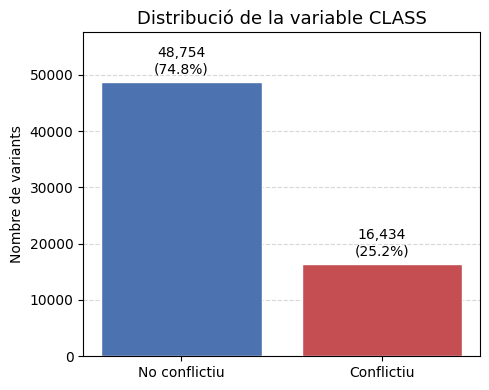

In [5]:
# Distribució de la variable objectiu (CLASS)
CLASS_LABELS = {0: "No conflictiu", 1: "Conflictiu"}
COLORS = ["#4C72B0", "#C44E52"]

counts = df["CLASS"].value_counts().sort_index()
labels = [CLASS_LABELS[i] for i in counts.index]
pcts   = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(5, 4))

bars = ax.bar(labels, counts.values, color=COLORS, edgecolor="white")
for bar, n, pct in zip(bars, counts.values, pcts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + counts.max() * 0.02,
            f"{n:,}\n({pct:.1f}%)",
            ha="center", va="bottom", fontsize=10)
ax.set_title("Distribució de la variable CLASS", fontsize=13)
ax.set_ylabel("Nombre de variants")
ax.set_ylim(0, counts.max() * 1.18)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## Valors nuls

L’anàlisi dels valors nuls permet avaluar la qualitat i completitud del dataset. El gràfic de percentatge de valors absents mostra que diverses variables presenten una proporció molt elevada de missing values, incloent columnes amb pràcticament absència total d’informació. Aquest patró suggereix que algunes variables poden no ser útils per al modelatge i haurien de ser considerades per eliminació en la fase de preprocessament. En canvi, altres variables amb percentatges intermedis de missing, com SIFT o PolyPhen, podrien contenir informació rellevant quan estan presents, i la seva absència podria fins i tot tenir valor informatiu. Per aquest motiu, es defineix un llindar del 95% de missing per identificar variables candidates a ser descartades en etapes posteriors.


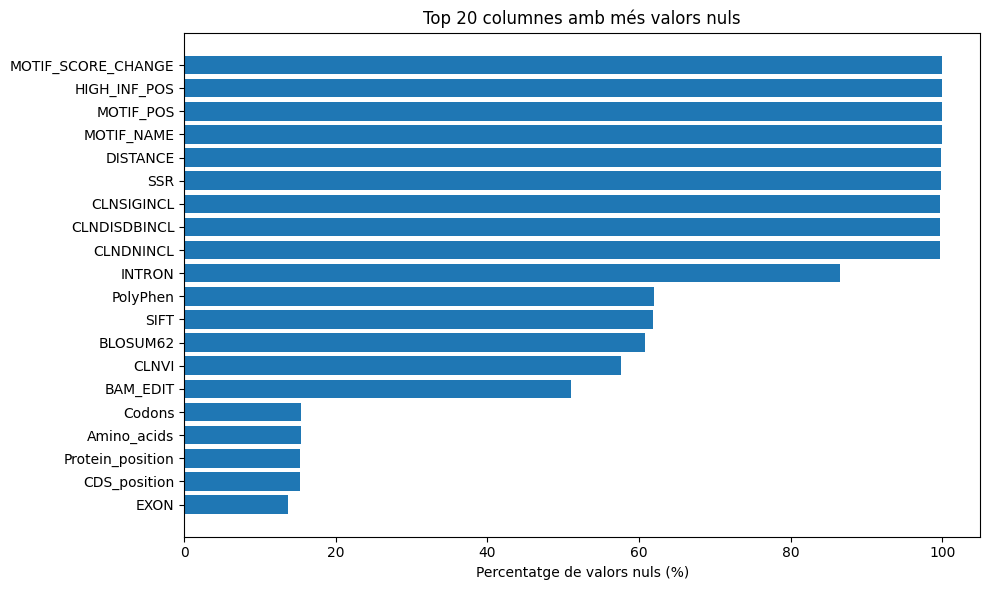

Columnes amb >95.0% valors nuls: 9
['MOTIF_SCORE_CHANGE', 'HIGH_INF_POS', 'MOTIF_POS', 'MOTIF_NAME', 'DISTANCE', 'SSR', 'CLNSIGINCL', 'CLNDISDBINCL', 'CLNDNINCL']


In [6]:
# Valors nuls globals
missing_tbl = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .to_frame("missing_%")
)
missing_tbl["dtype"] = df.dtypes.astype(str)
missing_tbl["nunique"] = df.nunique(dropna=True)
missing_tbl["n_missing"] = df.isna().sum()

# Principals columnes amb mes valors nuls
top_n = 20
top_missing = missing_tbl[missing_tbl["missing_%"] > 0].head(top_n).copy()

plt.figure(figsize=(10, 6))
plt.barh(top_missing.index[::-1], top_missing["missing_%"][::-1])
plt.xlabel("Percentatge de valors nuls (%)")
plt.title(f"Top {top_n} columnes amb més valors nuls")
plt.tight_layout()
plt.show()

# Columnes que superen el llindar
DROP_MISSING_THRESHOLD = 95.0
cols_drop_missing = missing_tbl.index[missing_tbl["missing_%"] > DROP_MISSING_THRESHOLD].tolist()
print(f"Columnes amb >{DROP_MISSING_THRESHOLD}% valors nuls: {len(cols_drop_missing)}")
print(cols_drop_missing[:30])



## Valors nuls per Classe (CLASS)

L’anàlisi del percentatge de valors absents segmentat per classe mostra que, en general, els valors nuls son similars entre **CLASS=0** i **CLASS=1**. Tot i que s’observen petites diferències en algunes variables, aquestes són moderades i no indiquen un patró clarament diferenciat entre classes. Per tant, la presència de valors nuls no sembla estar fortament associada amb la variable objectiu. 

/var/folders/tl/5pdn6vld70l0ndj9lvltyvxw0000gn/T/ipykernel_28172/2547060561.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_cls = df.groupby(target).apply(lambda g: g.isna().mean() * 100).T


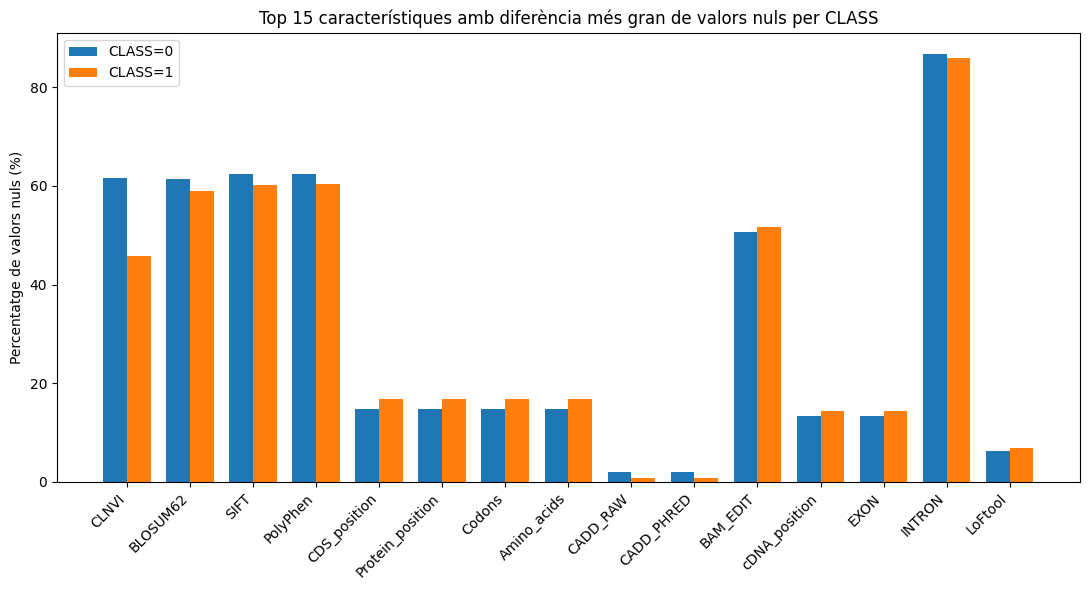

In [7]:
# Valors nuls per classe
target = "CLASS"

# Percentatge de valors nuls per columna i classe
missing_by_cls = df.groupby(target).apply(lambda g: g.isna().mean() * 100).T
missing_by_cls = missing_by_cls.drop(index=target, errors="ignore")

# Diferencia absoluta de valors nuls entre classes
missing_by_cls["diff_abs"] = (missing_by_cls[0] - missing_by_cls[1]).abs()

top_n = 15
top = missing_by_cls.sort_values("diff_abs", ascending=False).head(top_n)

x = np.arange(len(top.index))
width = 0.38

plt.figure(figsize=(11, 6))
plt.bar(x - width/2, top[0].values, width, label="CLASS=0")
plt.bar(x + width/2, top[1].values, width, label="CLASS=1")

plt.xticks(x, top.index, rotation=45, ha="right")
plt.ylabel("Percentatge de valors nuls (%)")
plt.title(f"Top {top_n} característiques amb diferència més gran de valors nuls per CLASS")
plt.legend()
plt.tight_layout()
plt.show()


## Variables Genòmiques Bàsiques: CHROM, POS, REF i ALT

Les variables genòmiques bàsiques descriuen la localització i la naturalesa molecular de cada variant. **CHROM** identifica el cromosoma on es troba la variant, **POS** indica la seva posició exacta dins del cromosoma, mentre que **REF** i **ALT** representen respectivament l’al·lel de referència i l’al·lel alternatiu observat. Aquestes variables constitueixen la definició única de cada variant i són essencials per comprendre la seva distribució i possible relació amb la presència de conflictes en la classificació.

### Distribució de CLASS per Cromosoma

El gràfic mostra el nombre absolut de variants consistents i conflictives per cromosoma. S’observa que alguns cromosomes, com el cromosoma 2, presenten un volum total de variants considerablement superior, tant en variants consistents com conflictives. Aquest resultat reflecteix principalment el nombre total de variants registrades en cada cromosoma i no necessàriament una major propensió al conflicte.


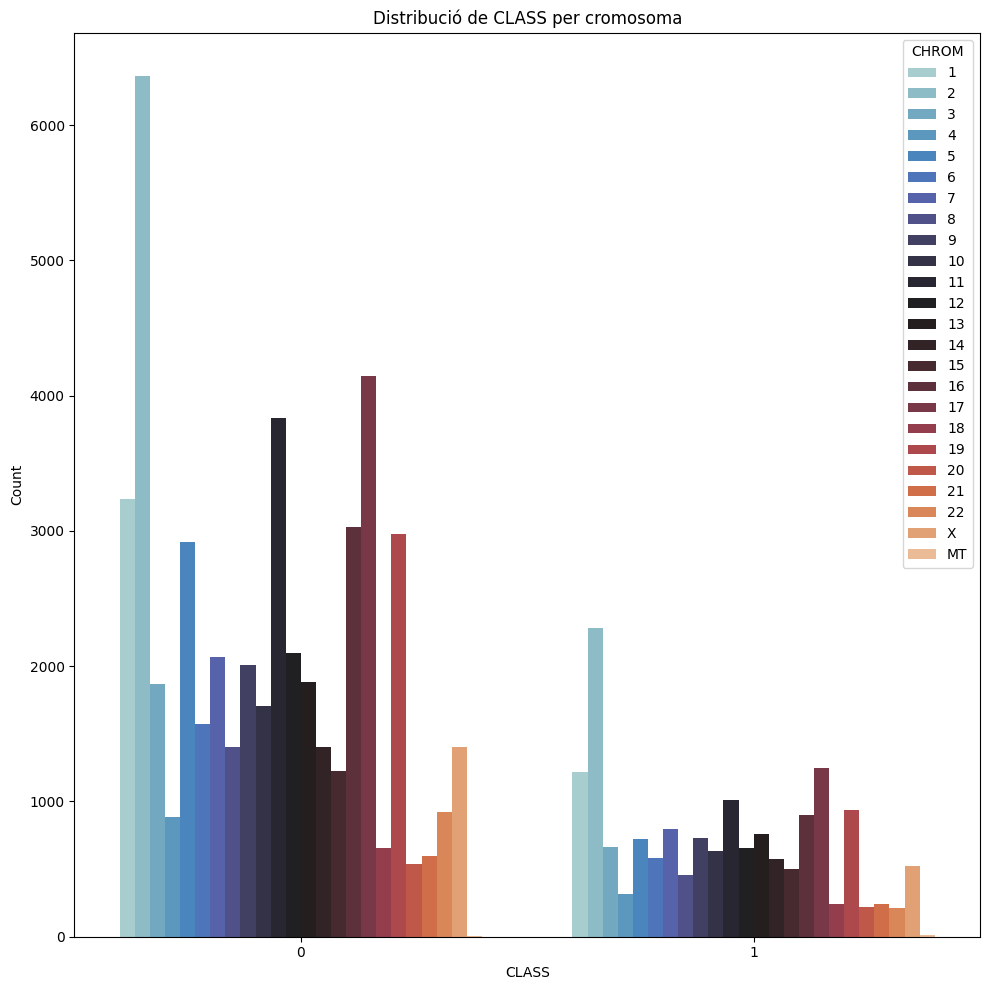

In [8]:
# Variables genòmiques bàsiques

basic_cols = ["CHROM", "POS", "REF", "ALT"]
for c in basic_cols:
    assert c in df.columns, f"Falta columna: {c}"

# Recompte de classes per cromosoma
plt.figure(figsize=(10, 10))
sns.countplot(x="CLASS", data=df, hue="CHROM", palette="icefire")
plt.title("Distribució de CLASS per cromosoma")
plt.xlabel("CLASS")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Taxa de Conflicte per Cromosoma

El gràfic mostra la proporció de variants conflictives dins de cada cromosoma, permetent comparar el risc relatiu de discrepància entre laboratoris de manera normalitzada. S’observa que, excepte el cromosoma mitocondrial (MT), que presenta una taxa considerablement superior però amb un nombre reduït de registres, la majoria de cromosomes mostren valors relativament homogenis, situats aproximadament entre el 18% i el 29%.

Aquesta distribució suggereix que el conflicte en la classificació no es concentra de manera marcada en cromosomes específics, sinó que es distribueix de forma bastant uniforme al llarg del genoma. Les diferències observades són moderades i podrien estar influïdes pel volum de variants disponibles en cada cromosoma.

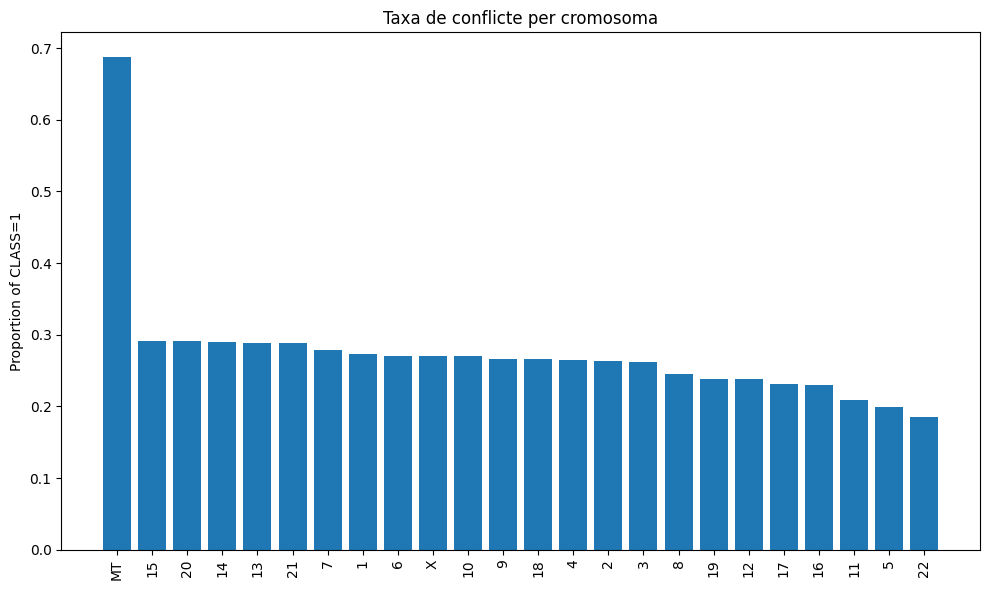

In [9]:
# Taxa de conflicte per cromosoma
chrom_conflict_rate = (
    df.groupby("CHROM")["CLASS"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
plt.bar(chrom_conflict_rate.index, chrom_conflict_rate.values)
plt.ylabel("Proportion of CLASS=1")
plt.title("Taxa de conflicte per cromosoma")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


### Distribució de la Posició Genòmica (POS)

L’histograma de la variable **POS** mostra que la distribució de variants al llarg del genoma no és uniforme, sinó que presenta múltiples pics i regions amb elevada concentració de registres. Aquest comportament suggereix l’existència de zones genòmiques amb major densitat de variants reportades, possiblement associades a gens clínicament rellevants o a regions àmpliament estudiades.

La major concentració observada en rangs baixos de posició pot estar relacionada amb la longitud variable dels cromosomes i amb el fet que **POS** representa coordenades internes a cada cromosoma. 

En conjunt, la variable **POS** reflecteix l’heterogeneïtat espacial de les variants en el genoma, però per si sola no permet inferir directament el risc de conflicte sense considerar el context cromosòmic o funcional.

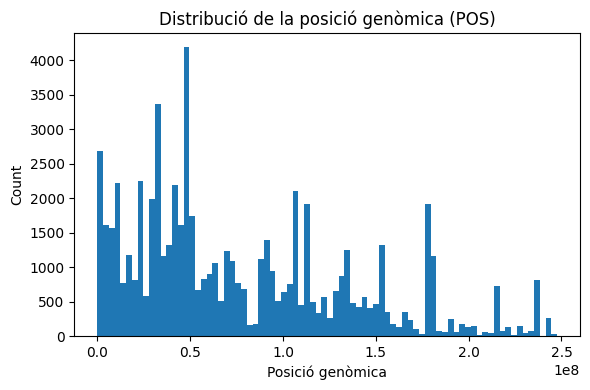

In [10]:
# Distribucio de POS
plt.figure(figsize=(6, 4))
plt.hist(df["POS"], bins=80)
plt.title("Distribució de la posició genòmica (POS)")
plt.xlabel("Posició genòmica")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Distribució dels Al·lels de Referència (REF) i Alternatius (ALT)

L’anàlisi de les freqüències dels valors més comuns de **REF** i **ALT** confirma que la gran majoria de variants corresponen a substitucions simples de nucleòtids (A, C, G i T), és a dir, *Single Nucleotide Variants (SNVs)*. Les combinacions de múltiples nucleòtids, associades a insercions o delecions curtes, representen una proporció molt reduïda del conjunt de dades.

S’observa una lleugera asimetria entre els nucleòtids de referència i els alternatius, amb una major presència de C i G en **REF** i de T i A en **ALT**. En conjunt, aquesta distribució indica que el problema de classificació es concentra principalment en variants puntuals.

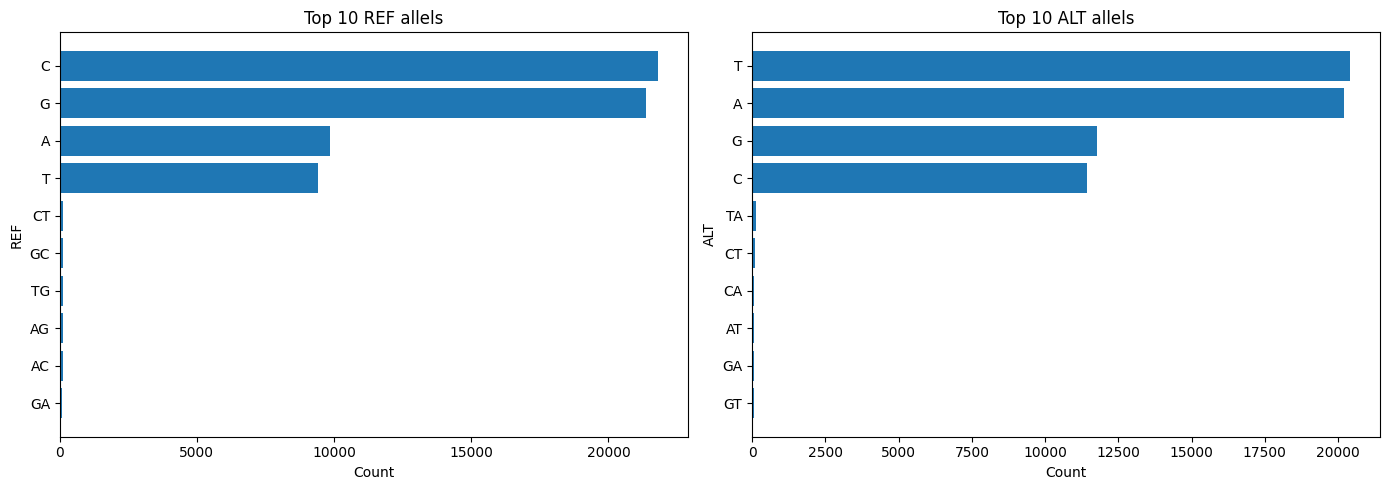

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# REF
ref_counts = df["REF"].value_counts().head(10)
axes[0].barh(ref_counts.index[::-1], ref_counts.values[::-1])
axes[0].set_title("Top 10 REF allels")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("REF")

# ALT
alt_counts = df["ALT"].value_counts().head(10)
axes[1].barh(alt_counts.index[::-1], alt_counts.values[::-1])
axes[1].set_title("Top 10 ALT allels")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("ALT")

plt.tight_layout()
plt.show()


### Distribució de les Freqüències

Els histogrames mostren que les tres variables presenten una distribució fortament asimètrica cap a la dreta, amb una elevada concentració de valors molt propers a zero. Aquest comportament és coherent amb la naturalesa del dataset, ja que la majoria de variants clíniques són rares en la població general. La forta asimetria suggereix que en fases posteriors podria ser convenient aplicar transformacions com ara escala logarítmica o discretització per reduir l’efecte de la cua llarga.

### Comparació per Classe

Els boxplots segmentats per `CLASS` indiquen que la mediana de les freqüències al·lèliques és pràcticament nul·la en ambdues classes, fet que confirma que la majoria de variants són rares independentment del seu estat de conflicte. Tanmateix, s’observa una lleugera diferència en la dispersió i en la distribució de valors no nuls, suggerint que les variants conflictives tendeixen a concentrar-se en rangs de baixa freqüència però no extremadament rars. Aquest patró és coherent amb la pràctica clínica, on les variants molt comunes solen estar clarament classificades com a benignes, mentre que variants rares poden generar més incertesa i discrepàncies entre laboratoris.

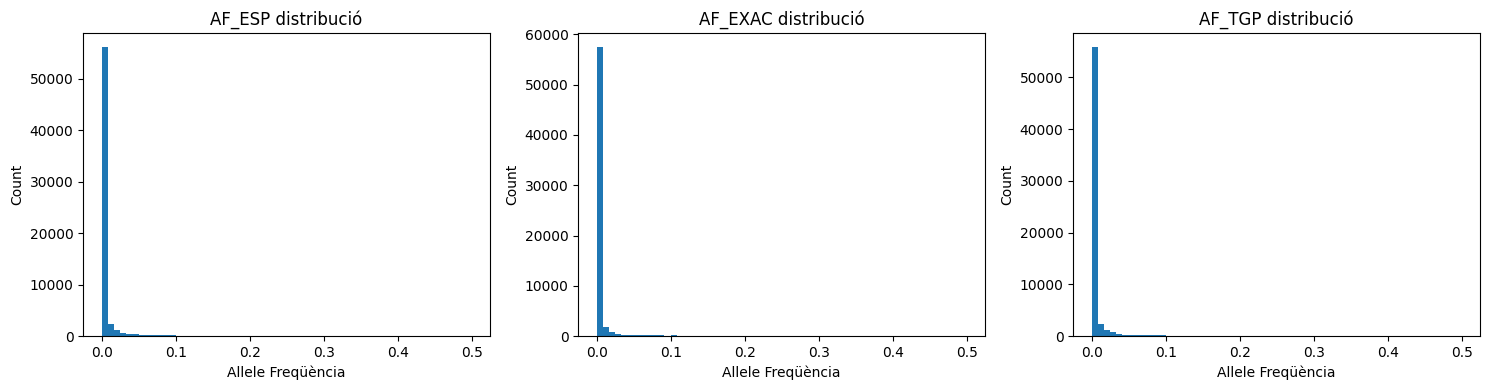

/var/folders/tl/5pdn6vld70l0ndj9lvltyvxw0000gn/T/ipykernel_28172/2412561306.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([data0, data1], labels=["0", "1"], showfliers=False)
/var/folders/tl/5pdn6vld70l0ndj9lvltyvxw0000gn/T/ipykernel_28172/2412561306.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([data0, data1], labels=["0", "1"], showfliers=False)
/var/folders/tl/5pdn6vld70l0ndj9lvltyvxw0000gn/T/ipykernel_28172/2412561306.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([data0, data1], labels=["0", "1"], showfliers=False)


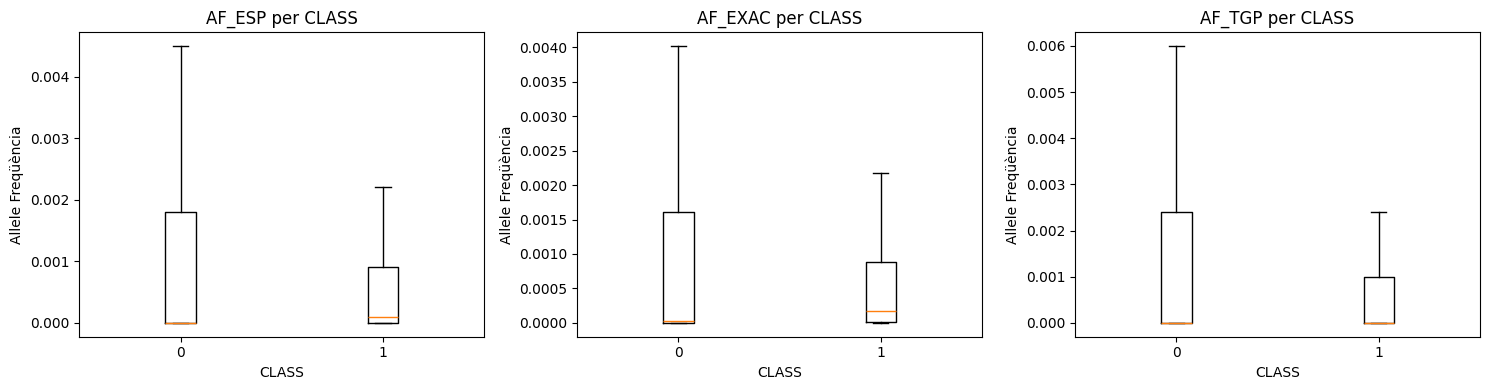

In [12]:
# Frequencies alleliques
af_cols = [c for c in ["AF_ESP", "AF_EXAC", "AF_TGP"] if c in df.columns]

# Convertim a numeric i assignem NaN quan no es pot convertir
for c in af_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Histogrames
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(af_cols):
    axes[i].hist(df[col].dropna(), bins=60)
    axes[i].set_title(f"{col} distribució")
    axes[i].set_xlabel("Allele Freqüència")
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

# Diagrames de caixa per classe
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(af_cols):
    data0 = df.loc[df["CLASS"] == 0, col].dropna()
    data1 = df.loc[df["CLASS"] == 1, col].dropna()
    axes[i].boxplot([data0, data1], labels=["0", "1"], showfliers=False)
    axes[i].set_title(f"{col} per CLASS")
    axes[i].set_xlabel("CLASS")
    axes[i].set_ylabel("Allele Freqüència")

plt.tight_layout()
plt.show()



## Correlació de Variables Numèriques amb CLASS

La matriu de correlació permet analitzar les relacions lineals entre les variables numèriques del dataset, incloent la variable objectiu **CLASS**. Les correlacions observades amb **CLASS** són generalment baixes en valor absolut, fet que indica que no existeix un únic predictor numèric amb forta relació lineal amb la presència de conflicte. Això suggereix que el patró predictiu és probablement multivariable i pot incloure interaccions no lineals entre característiques.

### Observacions Relevants de la Matriu

S’observa una alta correlació positiva entre **CADD_PHRED** i **CADD_RAW**, fet esperable ja que ambdues mesures provenen del mateix sistema d’anotació funcional. De manera similar, les tres freqüències al·lèliques presenten correlacions elevades entre si, atès que descriuen la mateixa propietat en diferents cohorts poblacionals. En canvi, la relació entre aquestes variables i **CLASS** és negativa però moderada, la qual cosa reforça la idea que les variants més freqüents tendeixen a presentar menys conflicte. Globalment, l’absència de correlacions lineals fortes amb la variable objectiu orienta cap a l’ús de models capaços de capturar relacions no lineals i interaccions complexes entre característiques.

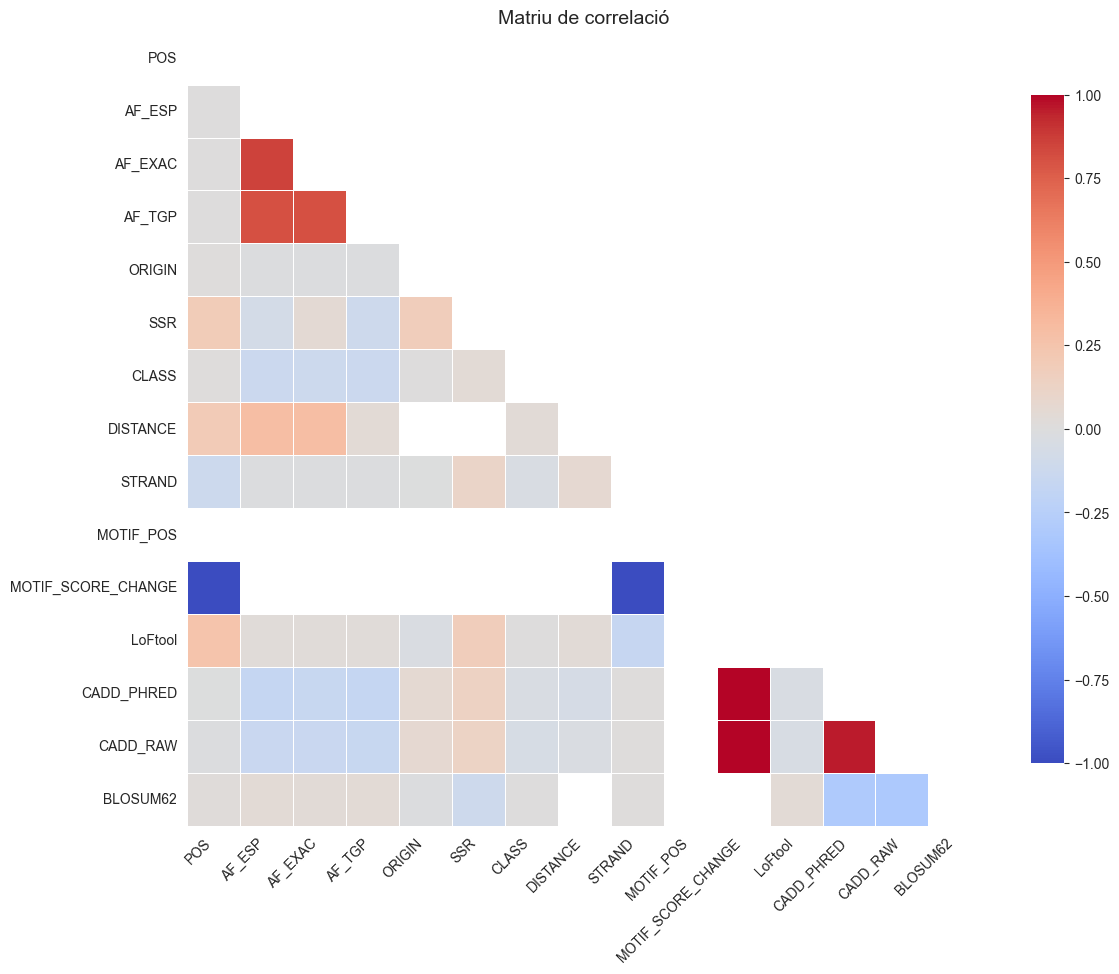

In [13]:
# Matriu de correlacio (variables numeriques)
num_df = df.select_dtypes(include=[np.number]).copy()
corr = num_df.corr()
sns.set_style("white")  

# Mascara per ocultar el triangle superior
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Matriu de correlació", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



## Variables categòriques i taxa de conflicte (CLASS)

Els gràfics mostren, per a cada categoria d’una variable, la proporció de variants conflictives (**CLASS=1**) mitjançant les barres blaves, i el nombre total de registres disponibles mitjançant la línia taronja.

La interpretació correcta requereix considerar simultàniament ambdues dimensions: una taxa de conflicte elevada en una categoria amb pocs casos pot ser deguda a soroll estadístic, mentre que diferències observades en categories amb molts registres són més robustes i fiables.

En general, es detecta que algunes variables funcionals (com **IMPACT**, **SIFT** o **PolyPhen**) mostren variacions moderades en la taxa de conflicte entre categories. Això suggereix que el tipus d’anotació funcional podria estar relacionat amb la probabilitat de desacord entre laboratoris. 

En variables d’alta cardinalitat com **SYMBOL**, les diferències s’han d’interpretar amb cautela, ja que poden reflectir el volum de submissions o la complexitat clínica associada a determinats gens més que un efecte biològic directe.

En conjunt, aquests resultats indiquen que una part del senyal predictiu es troba en variables categòriques, especialment quan les diferències de taxa es donen en categories amb volum de dades suficient.

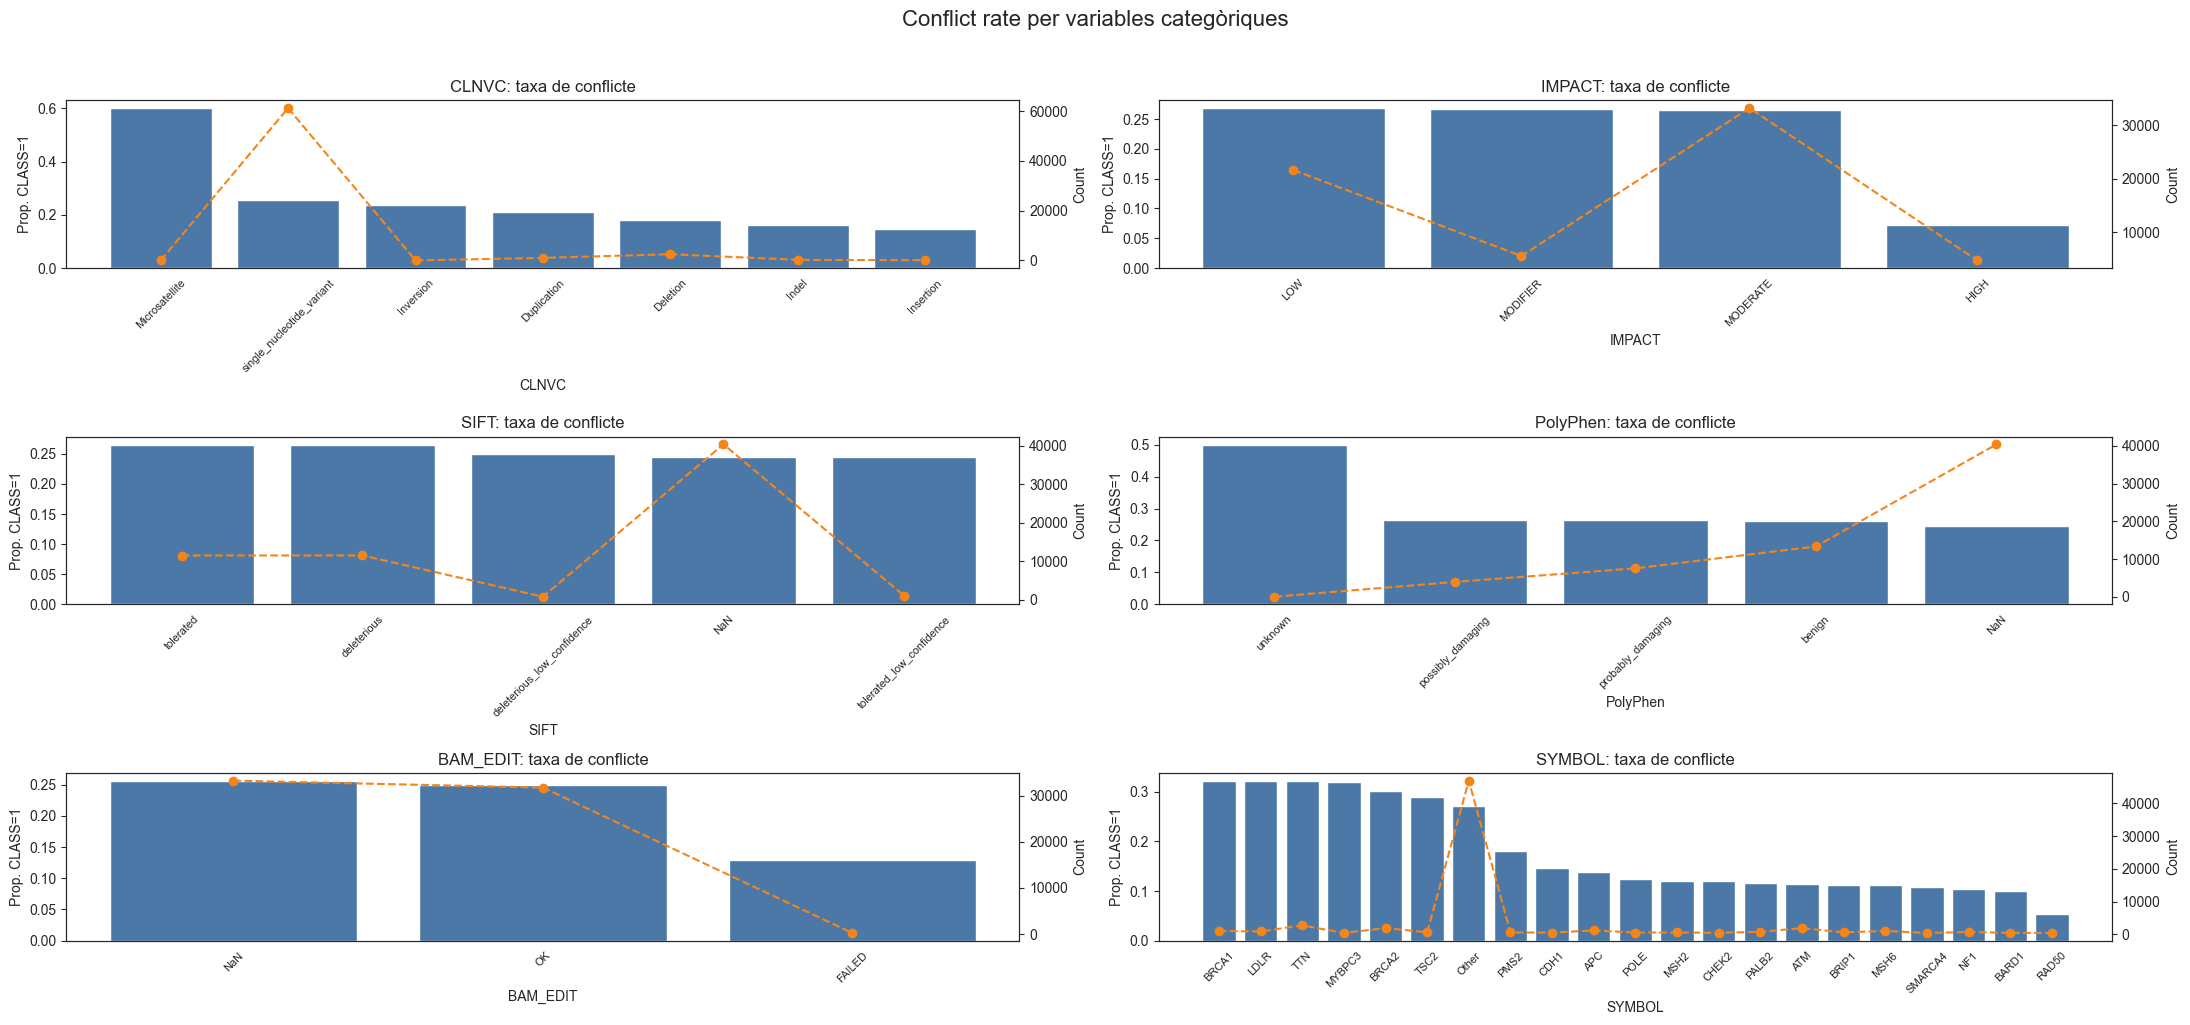

In [14]:
sns.set_style("white")

def plot_conflict_rate_cat(ax, df, col, target="CLASS", top_n=15):
    tmp = df[[col, target]].copy()
    tmp[col] = tmp[col].astype("object").fillna("NaN")

    # Si hi ha massa categories, agrupem les no principals a "Other"
    vc = tmp[col].value_counts()
    if vc.shape[0] > top_n:
        top = vc.head(top_n).index
        tmp[col] = np.where(tmp[col].isin(top), tmp[col], "Other")

    rate = tmp.groupby(col)[target].mean().sort_values(ascending=False)
    cnt = tmp[col].value_counts().reindex(rate.index)

    ax.bar(rate.index.astype(str), rate.values, color="#4C78A8")
    ax.set_title(f"{col}: taxa de conflicte")
    ax.set_ylabel("Prop. CLASS=1")
    ax.set_xlabel(col)
    ax.tick_params(axis="x", rotation=45, labelsize=8)

    # Segon eix per veure volum de mostres per categoria
    ax2 = ax.twinx()
    ax2.plot(range(len(cnt)), cnt.values, marker="o", linestyle="--", color="#F58518", linewidth=1.5)
    ax2.set_ylabel("Count")

# 6 grafics en graella 2x3
vars_to_plot = [
    ("CLNVC", 10),
    ("IMPACT", 10),
    ("SIFT", 10),
    ("PolyPhen", 10),
    ("BAM_EDIT", 10),
    ("SYMBOL", 20),
]

available = [(c, n) for c, n in vars_to_plot if c in df.columns]

fig, axes = plt.subplots(3, 2, figsize=(22, 10))
axes = axes.flatten()

for i, (col, top_n) in enumerate(available[:6]):
    plot_conflict_rate_cat(axes[i], df, col, top_n=top_n)

# Si en falten, amaguem els subplots buits
for j in range(len(available[:6]), 6):
    axes[j].axis("off")

fig.suptitle("Conflict rate per variables categòriques", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()



## Particio de dades (train/validation/test)

Es defineix una particio fixa per garantir comparacions justes entre models:
- 90% per **train_val** i 10% per **test**
- mateixa **random_state** en tots els splits

In [15]:

TARGET_COL = "CLASS"
RANDOM_STATE = 42
TEST_SIZE = 0.10

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# 90% train_val, 10% test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

## Processat de dades

In [16]:

cols_high_missing = [
    'MOTIF_SCORE_CHANGE',
    'HIGH_INF_POS',
    'MOTIF_POS',
    'MOTIF_NAME',
    'DISTANCE',
    'SSR',
    'CLNSIGINCL',
    'CLNDISDBINCL',
    'CLNDNINCL'
]

# Eliminem les columnes amb molt missing dels conjunts que realment fem servir
X_train_val = X_train_val.drop(columns=cols_high_missing, errors="ignore")
X_test = X_test.drop(columns=cols_high_missing, errors="ignore")

# Columnes numèriques i categòriques definides sobre train_val
num_cols = X_train_val.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train_val.select_dtypes(exclude=np.number).columns.tolist()

# Preprocessat
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=20)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)

## SVM

Model inicial, ROC AUC per fold: [0.72286829 0.72305617 0.72225168 0.72468958 0.7250399 ]
ROC AUC mitjà: 0.7235811244135251
Fitting 5 folds for each of 10 candidates, totalling 50 fits


Millors paràmetres: {'model__C': 0.01, 'model__class_weight': None}
Millor CV ROC AUC: 0.741823578424962
Resultats del test ROC AUC: 0.7430504134925957
Confusion matrix:
 [[4669  207]
 [1350  293]]


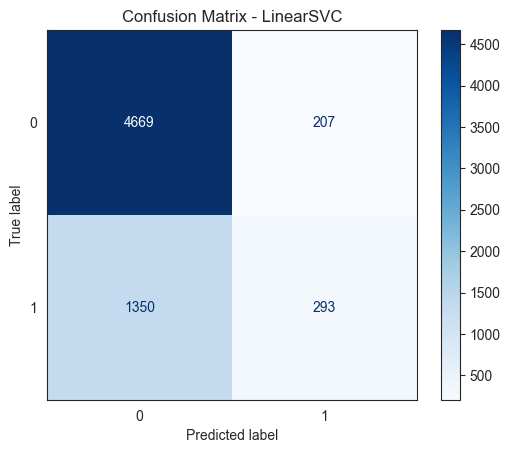

In [17]:

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

linear_svm = LinearSVC(
    random_state=42,
    max_iter=100000,
    dual=False,
    loss="squared_hinge"
)

pipeline_linsvm = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", linear_svm)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline_linsvm,
    X_train_val, y_train_val,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("Model inicial, ROC AUC per fold:", scores)
print("ROC AUC mitjà:", scores.mean())

param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1.0, 10.0],
    "model__class_weight": [None, "balanced"]
}

grid_svm = GridSearchCV(
    estimator=pipeline_linsvm,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_svm.fit(X_train_val, y_train_val)

print("\n")
print("Millors paràmetres:", grid_svm.best_params_)
print("Millor CV ROC AUC:", grid_svm.best_score_)

# Evaluació final al test
best_model = grid_svm.best_estimator_

test_scores = best_model.decision_function(X_test)
y_test_pred = best_model.predict(X_test)
test_auc = roc_auc_score(y_test, test_scores)
cm_svm = confusion_matrix(y_test, y_test_pred)

print("Resultats del test ROC AUC:", test_auc)
print("Confusion matrix:\n", cm_svm)

ConfusionMatrixDisplay(confusion_matrix=cm_svm).plot(cmap="Blues")
plt.title("Confusion Matrix - LinearSVC")
plt.show()

auc_svm = roc_auc_score(y_test, test_scores)


## MLP

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Millors paràmetres: {'model__alpha': 0.001, 'model__hidden_layer_sizes': (64, 32), 'model__learning_rate_init': 0.001}
Millor CV ROC AUC: 0.7594953476892968
Resultats del test ROC AUC: 0.7632500872521055
Confusion matrix:
 [[4544  332]
 [1200  443]]


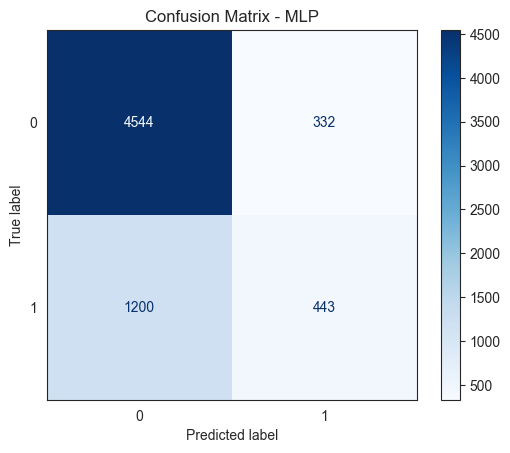

In [18]:

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
    module=r"sklearn\.utils\.extmath"
)

mlp = MLPClassifier(
    activation="relu",
    solver="adam",
    hidden_layer_sizes=(128,),
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    tol=1e-4,
    max_iter=300,
    random_state=42
)

pipeline_mlp = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", mlp)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    "model__hidden_layer_sizes": [(64,), (128,), (64, 32)],
    "model__alpha":              [1e-3, 5e-3],
    "model__learning_rate_init": [1e-4, 5e-4, 1e-3],
}

grid_mlp = GridSearchCV(
    pipeline_mlp,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=1,
    verbose=1,
    error_score="raise"
)

grid_mlp.fit(X_train_val, y_train_val)

print("Millors paràmetres:", grid_mlp.best_params_)
print("Millor CV ROC AUC:", grid_mlp.best_score_)

best_mlp = grid_mlp.best_estimator_
y_test_proba = best_mlp.predict_proba(X_test)[:, 1]
y_test_pred = best_mlp.predict(X_test)
auc_mlp = roc_auc_score(y_test, y_test_proba)
cm_mlp = confusion_matrix(y_test, y_test_pred)
print("Resultats del test ROC AUC:", roc_auc_score(y_test, y_test_proba))
print("Confusion matrix:\n", cm_mlp)

ConfusionMatrixDisplay(confusion_matrix=cm_mlp).plot(cmap="Blues")
plt.title("Confusion Matrix - MLP")
plt.show()


## Ridge logistic regression

Model inicial, ROC AUC per fold: [0.73810477 0.7383532  0.73727617 0.73939833 0.7397779 ]
ROC AUC mitjà: 0.7385820753919736
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Millors paràmetres: {'model__C': 0.1, 'model__class_weight': None}
Millor CV ROC AUC: 0.7488114894745015
Resultats del test ROC AUC: 0.74925692162589
Confusion matrix:
 [[4508  368]
 [1222  421]]


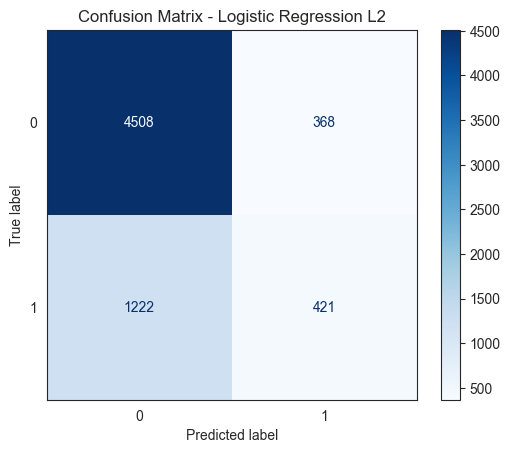

In [19]:

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

logreg_l2 = LogisticRegression(
    penalty="l2",
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

pipeline_logreg_l2 = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", logreg_l2)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline_logreg_l2,
    X_train_val, y_train_val,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("Model inicial, ROC AUC per fold:", scores)
print("ROC AUC mitjà:", scores.mean())

param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1.0, 10.0],
    "model__class_weight": [None, "balanced"]
}

grid_l2 = GridSearchCV(
    estimator=pipeline_logreg_l2,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_l2.fit(X_train_val, y_train_val)

print("Millors paràmetres:", grid_l2.best_params_)
print("Millor CV ROC AUC:", grid_l2.best_score_)
# evaluació final al test
best_model = grid_l2.best_estimator_
y_test_proba = best_model.predict_proba(X_test)[:, 1]
y_test_pred = best_model.predict(X_test)
test_auc = roc_auc_score(y_test, y_test_proba)
auc_l2 = roc_auc_score(y_test, y_test_proba)
cm_l2 = confusion_matrix(y_test, y_test_pred)

print("Resultats del test ROC AUC:", test_auc)
print("Confusion matrix:\n", cm_l2)

ConfusionMatrixDisplay(confusion_matrix=cm_l2).plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression L2")
plt.show()

## Lasso logistic regression

Model inicial, ROC AUC per fold: [0.74320886 0.7413681  0.74075044 0.74547103 0.74360207]
ROC AUC mitjà: 0.7428801008863749
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Millors paràmetres: {'model__C': 1.0, 'model__class_weight': None}
Millor CV ROC AUC: 0.7428801008863749
Test ROC AUC: 0.7474245025881047
Confusion matrix:
 [[4367  509]
 [1114  529]]


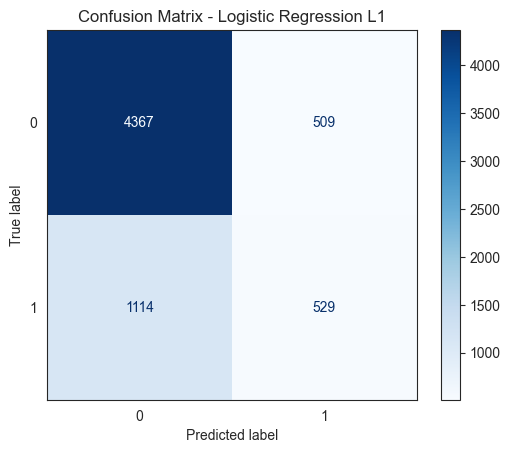

In [20]:

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

logreg_l1 = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

pipeline_logreg_l1 = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", logreg_l1)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline_logreg_l1,
    X_train_val, y_train_val,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("Model inicial, ROC AUC per fold:", scores)
print("ROC AUC mitjà:", scores.mean())

param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1.0, 10.0],
    "model__class_weight": [None, "balanced"]
}

grid_l1 = GridSearchCV(
    estimator=pipeline_logreg_l1,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_l1.fit(X_train_val, y_train_val)

print("Millors paràmetres:", grid_l1.best_params_)
print("Millor CV ROC AUC:", grid_l1.best_score_)

# evaliació final al test
best_model = grid_l1.best_estimator_

y_test_proba = best_model.predict_proba(X_test)[:, 1]
y_test_pred = best_model.predict(X_test)
test_auc = roc_auc_score(y_test, y_test_proba)
auc_l1 = roc_auc_score(y_test, y_test_proba)
cm_l1 = confusion_matrix(y_test, y_test_pred)

print("Test ROC AUC:", test_auc)
print("Confusion matrix:\n", cm_l1)

ConfusionMatrixDisplay(confusion_matrix=cm_l1).plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression L1")
plt.show()

## Decision Tree

Model inicial, ROC AUC per fold: [0.60633991 0.65743391 0.65219199 0.60180241 0.65337968]
ROC AUC mitjà: 0.6342295788291539
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Millors paràmetres: {'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__min_samples_leaf': 10, 'model__min_samples_split': 2}
Millor CV ROC AUC: 0.7578558728002259
Resultats del test ROC AUC: 0.7195520734046096
Confusion matrix:
 [[3591 1285]
 [ 611 1032]]


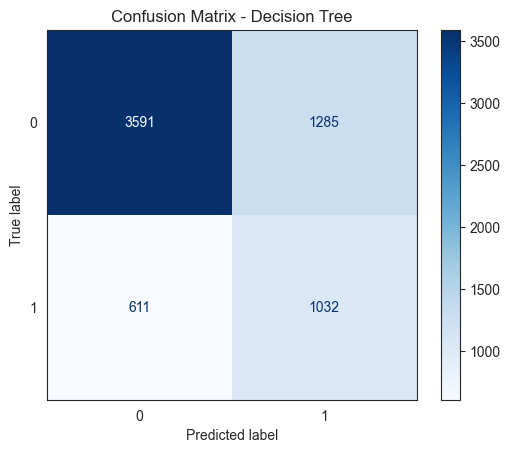

In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, roc_auc_score

# Model
dt_binary = DecisionTreeClassifier(
    random_state=42
)

# Pipeline
pipeline_dt_binary = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", dt_binary)
])

# CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Baseline CV score
scores = cross_val_score(
    pipeline_dt_binary,
    X_train_val, y_train_val,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)
print("Model inicial, ROC AUC per fold:", scores)
print("ROC AUC mitjà:", scores.mean())

# Hyperparameter grid
param_grid = {
    "model__max_depth":         [5, 10, 20, None],
    "model__min_samples_split": [2, 10, 20],
    "model__min_samples_leaf":  [1, 5, 10],
    "model__class_weight":      [None, "balanced"]
}

# Grid Search
grid_dt_binary = GridSearchCV(
    estimator=pipeline_dt_binary,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)
grid_dt_binary.fit(X_train_val, y_train_val)

print("\nMillors paràmetres:", grid_dt_binary.best_params_)
print("Millor CV ROC AUC:", grid_dt_binary.best_score_)

# Final evaluation on test
best_model = grid_dt_binary.best_estimator_
y_test_proba = best_model.predict_proba(X_test)[:, 1]
y_test_pred = best_model.predict(X_test)
test_auc = roc_auc_score(y_test, y_test_proba)
auc_dt_binary = roc_auc_score(y_test, y_test_proba)
cm_dt = confusion_matrix(y_test, y_test_pred)
print("Resultats del test ROC AUC:", test_auc)
print("Confusion matrix:\n", cm_dt)

ConfusionMatrixDisplay(confusion_matrix=cm_dt).plot(cmap="Blues")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

## Random Forest

Model inicial, ROC AUC per fold: [0.81043073 0.81100981 0.81552759 0.80820155 0.81297059]
ROC AUC mitjà: 0.8116280537569471
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Millors paràmetres: {'model__n_estimators': 100, 'model__min_samples_split': 10, 'model__min_samples_leaf': 1, 'model__max_features': 0.3, 'model__max_depth': 30, 'model__class_weight': None}
Millor CV ROC AUC: 0.8140363556963015
Resultats del test ROC AUC: 0.8269121067975757
Confusion matrix:
 [[4665  211]
 [1168  475]]


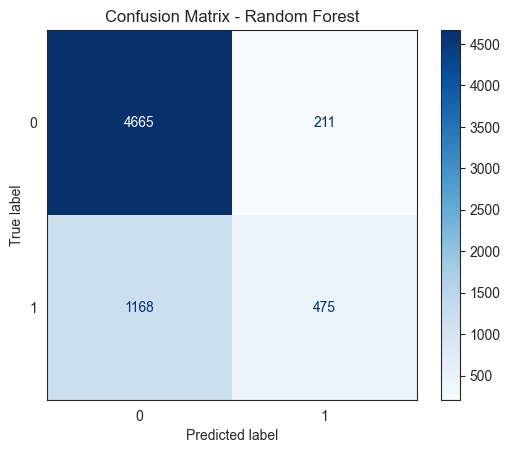

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay, roc_auc_score, classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# Model
rf_binary = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Pipeline
pipeline_rf_binary = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", rf_binary)
])

# CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Baseline CV score
scores = cross_val_score(
    pipeline_rf_binary,
    X_train_val, y_train_val,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)
print("Model inicial, ROC AUC per fold:", scores)
print("ROC AUC mitjà:", scores.mean())

# Hyperparameter grid
param_dist = {
    "model__n_estimators":      [100, 200, 300],
    "model__max_depth":         [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf":  [1, 2, 5],
    "model__max_features":      ["sqrt", 0.3],
    "model__class_weight":      [None, "balanced"]
}

# Randomized Search (consistent with your RF multiclass)
random_search_rf_binary = RandomizedSearchCV(
    estimator=pipeline_rf_binary,
    param_distributions=param_dist,
    n_iter=10,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42,
    refit=True
)
random_search_rf_binary.fit(X_train_val, y_train_val)

print("\nMillors paràmetres:", random_search_rf_binary.best_params_)
print("Millor CV ROC AUC:", random_search_rf_binary.best_score_)

# Final evaluation on test
best_model_rf_binary = random_search_rf_binary.best_estimator_
y_test_proba = best_model_rf_binary.predict_proba(X_test)[:, 1]
y_pred       = best_model_rf_binary.predict(X_test)

auc_rf_binary = roc_auc_score(y_test, y_test_proba)
cm_rf = confusion_matrix(y_test, y_pred)
print("Resultats del test ROC AUC:", auc_rf_binary)
print("Confusion matrix:\n", cm_rf)

ConfusionMatrixDisplay(confusion_matrix=cm_rf).plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()

## Corbes ROC AUC al conjunt de test

La imatge mostra les corbes ROC dels sis models avaluats sobre el conjunt de test: LinearSVC, MLP, Logistic Regression L2, Logistic Regression L1, Decision Tree i Random Forest. Tots es comparen respecte al classificador aleatori per valorar la seva capacitat discriminativa.
La comparacio visual de les corbes i dels valors AUC permet identificar quin model manté el millor equilibri entre sensibilitat i especificitat en el conjunt de test.
Aquesta figura resumeix el rendiment relatiu de tots els models binaris entrenats.

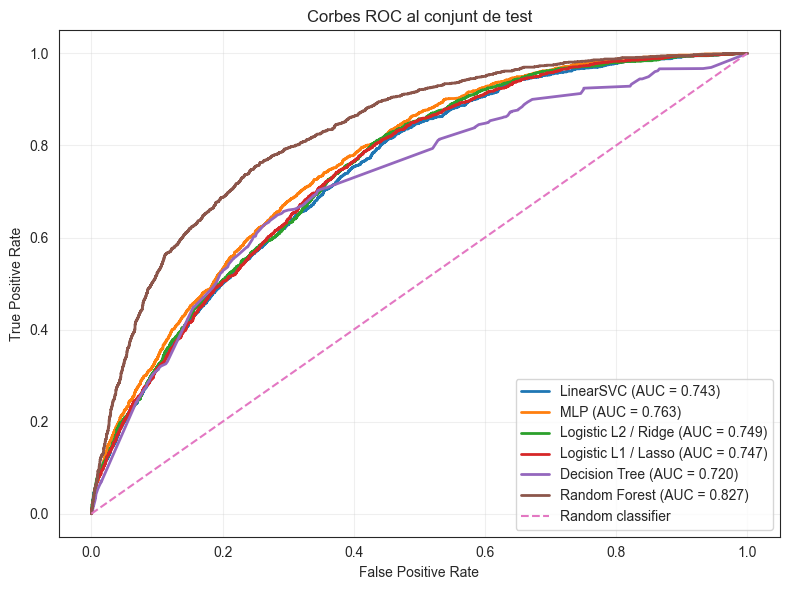

In [23]:

# --- Millors models ja entrenats amb GridSearchCV ---
best_svm = grid_svm.best_estimator_
best_mlp = grid_mlp.best_estimator_
best_logreg_l2 = grid_l2.best_estimator_
best_logreg_l1 = grid_l1.best_estimator_
best_dt = grid_dt_binary.best_estimator_
best_rf = random_search_rf_binary.best_estimator_

# --- Scores/probabilitats al conjunt de test ---
svm_scores = best_svm.decision_function(X_test)
mlp_scores = best_mlp.predict_proba(X_test)[:, 1]
l2_scores = best_logreg_l2.predict_proba(X_test)[:, 1]
l1_scores = best_logreg_l1.predict_proba(X_test)[:, 1]
dt_scores = best_dt.predict_proba(X_test)[:, 1]
rf_scores = best_rf.predict_proba(X_test)[:, 1]

# --- ROC curve points ---
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_scores)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, mlp_scores)
fpr_l2, tpr_l2, _ = roc_curve(y_test, l2_scores)
fpr_l1, tpr_l1, _ = roc_curve(y_test, l1_scores)
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_scores)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_scores)

# --- AUC ---
auc_svm = roc_auc_score(y_test, svm_scores)
auc_mlp = roc_auc_score(y_test, mlp_scores)
auc_l2 = roc_auc_score(y_test, l2_scores)
auc_l1 = roc_auc_score(y_test, l1_scores)
auc_dt = roc_auc_score(y_test, dt_scores)
auc_rf = roc_auc_score(y_test, rf_scores)

# --- Plot ---
plt.figure(figsize=(8, 6))

plt.plot(fpr_svm, tpr_svm, linewidth=2, label=f"LinearSVC (AUC = {auc_svm:.3f})")
plt.plot(fpr_mlp, tpr_mlp, linewidth=2, label=f"MLP (AUC = {auc_mlp:.3f})")
plt.plot(fpr_l2, tpr_l2, linewidth=2, label=f"Logistic L2 / Ridge (AUC = {auc_l2:.3f})")
plt.plot(fpr_l1, tpr_l1, linewidth=2, label=f"Logistic L1 / Lasso (AUC = {auc_l1:.3f})")
plt.plot(fpr_dt, tpr_dt, linewidth=2, label=f"Decision Tree (AUC = {auc_dt:.3f})")
plt.plot(fpr_rf, tpr_rf, linewidth=2, label=f"Random Forest (AUC = {auc_rf:.3f})")

# línia diagonal d'atzar
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Corbes ROC al conjunt de test")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Interpretablitat Logistic Regression

/Users/eliag/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 SHAP Ridge L2 


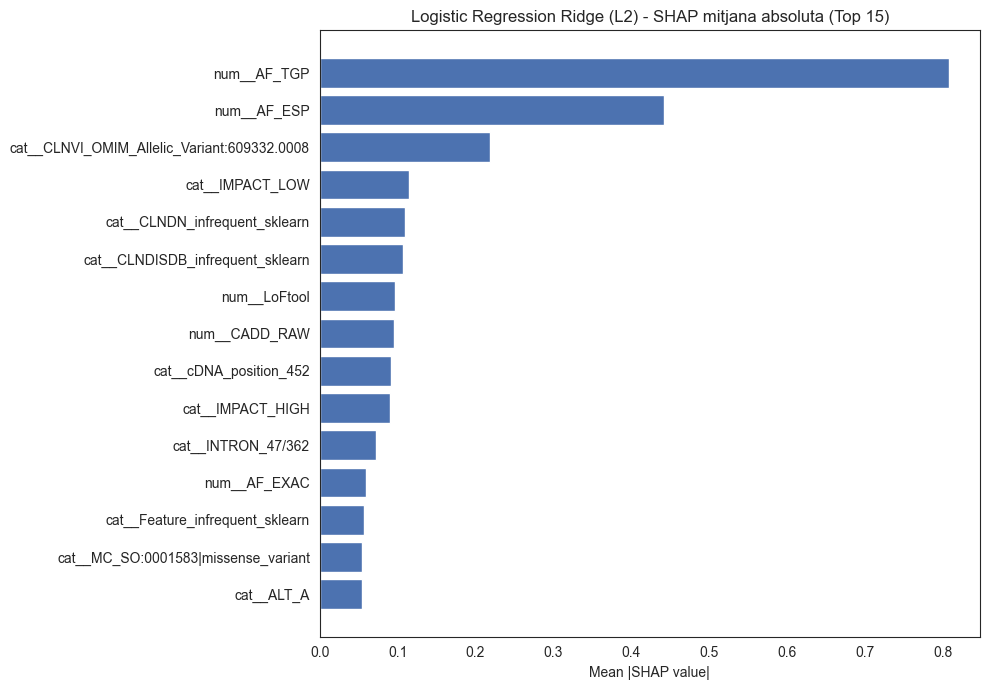

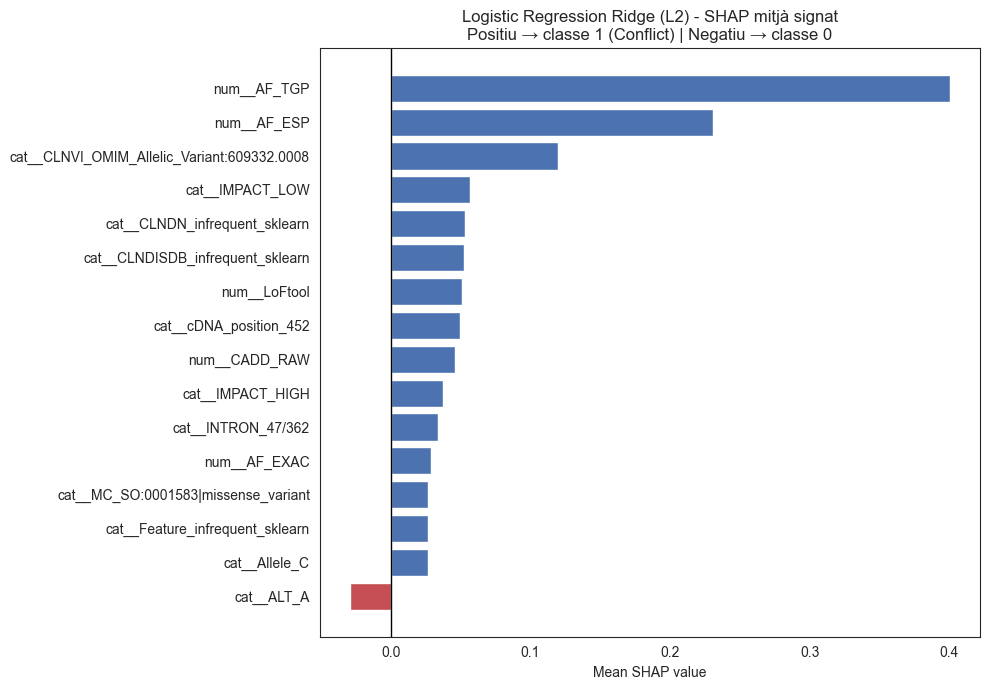

 SHAP Lasso L1 


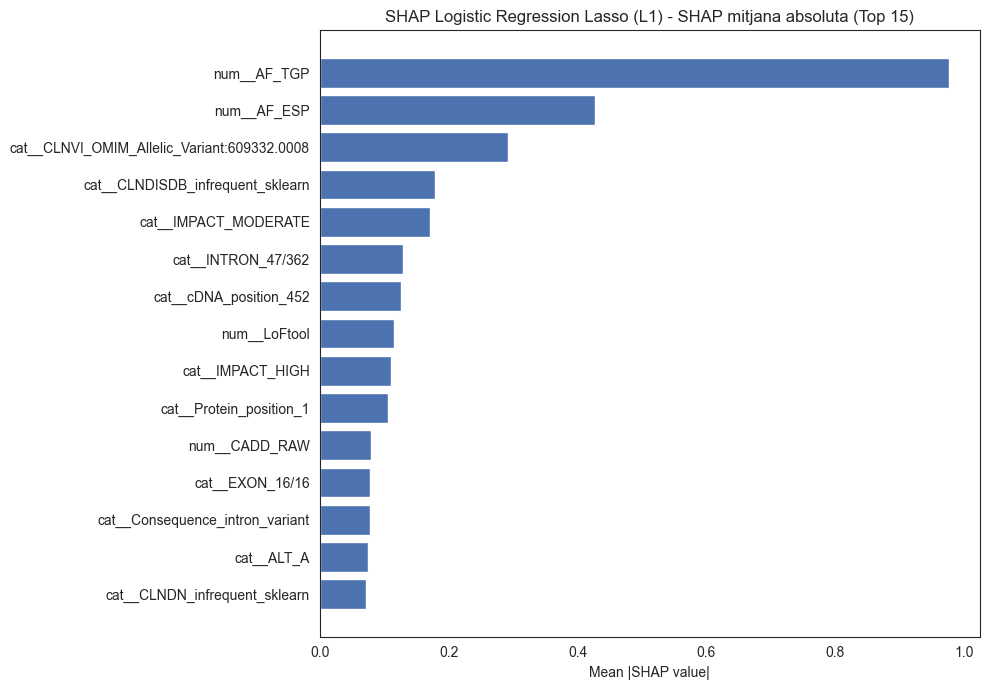

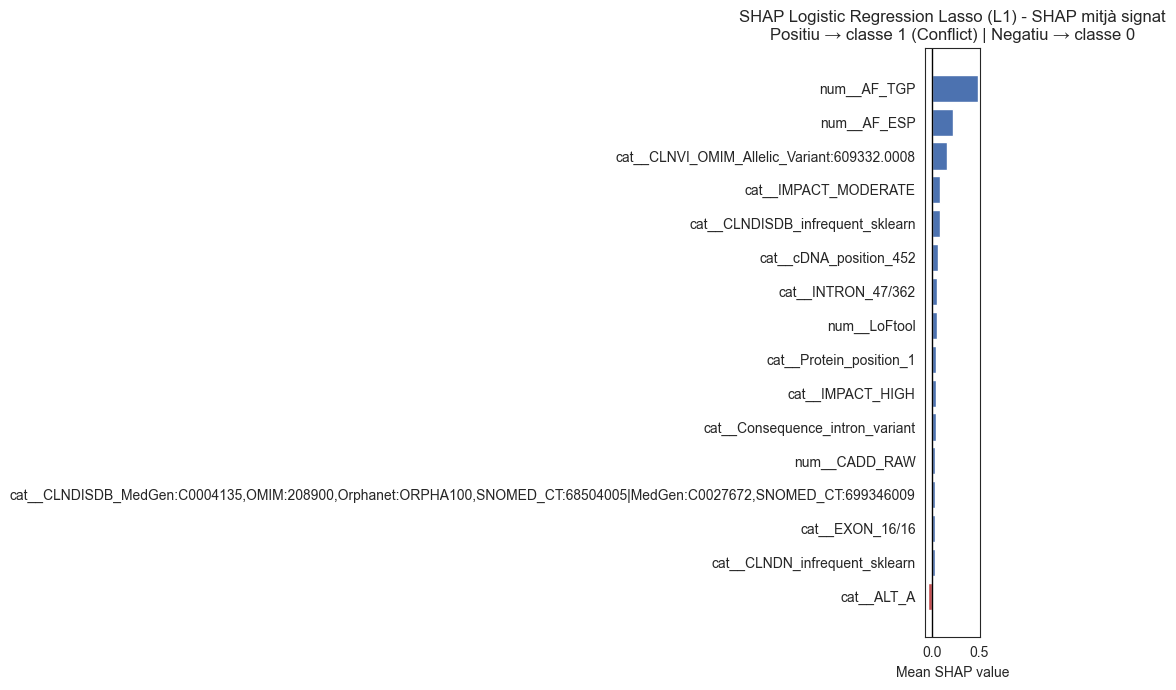

In [24]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Transformem X_test
X_test_transformed = grid_l2.best_estimator_.named_steps["preprocess"].transform(X_test)
feature_names = grid_l2.best_estimator_.named_steps["preprocess"].get_feature_names_out()

# Explainers
explainer_l2 = shap.LinearExplainer(grid_l2.best_estimator_.named_steps["model"], X_test_transformed)
explainer_l1 = shap.LinearExplainer(grid_l1.best_estimator_.named_steps["model"], X_test_transformed)

shap_values_l2 = explainer_l2.shap_values(X_test_transformed)
shap_values_l1 = explainer_l1.shap_values(X_test_transformed)


def plot_shap_linear(shap_values, feature_names, title_prefix, top_k=15):
    mean_abs  = np.abs(shap_values).mean(axis=0)
    mean_pos  = np.where(shap_values > 0, shap_values, 0).mean(axis=0)
    mean_neg  = np.where(shap_values < 0, shap_values, 0).mean(axis=0)

    shap_df = pd.DataFrame({
        "feature":       feature_names,
        "mean_abs_shap": mean_abs,
        "mean_pos_shap": mean_pos,
        "mean_neg_shap": mean_neg
    })

    top_abs = shap_df.nlargest(top_k, "mean_abs_shap").copy()
    top_pos = shap_df.nlargest(top_k, "mean_pos_shap").copy()
    top_neg = shap_df.nsmallest(top_k, "mean_neg_shap").copy()

    #  Gràfic 1: Top mitjana absoluta 
    top_abs_sorted = top_abs.sort_values("mean_abs_shap")
    plt.figure(figsize=(10, 7))
    plt.barh(top_abs_sorted["feature"], top_abs_sorted["mean_abs_shap"], color="#4C72B0")
    plt.title(f"{title_prefix} - SHAP mitjana absoluta (Top {top_k})")
    plt.xlabel("Mean |SHAP value|")
    plt.tight_layout()
    plt.show()

    # Gràfic 2: Positiu i negatiu combinat 
    plot_df = pd.concat([
        top_pos.assign(direction="Positive")[["feature", "mean_pos_shap", "direction"]]
               .rename(columns={"mean_pos_shap": "signed_shap"}),
        top_neg.assign(direction="Negative")[["feature", "mean_neg_shap", "direction"]]
               .rename(columns={"mean_neg_shap": "signed_shap"})
    ]).drop_duplicates(subset="feature", keep="first").sort_values("signed_shap")

    colors = ["#C44E52" if x < 0 else "#4C72B0" for x in plot_df["signed_shap"]]
    plt.figure(figsize=(10, 7))
    plt.barh(plot_df["feature"], plot_df["signed_shap"], color=colors)
    plt.axvline(0, color="black", linewidth=1)
    plt.title(f"{title_prefix} - SHAP mitjà signat\nPositiu → classe 1 (Conflict) | Negatiu → classe 0")
    plt.xlabel("Mean SHAP value")
    plt.tight_layout()
    plt.show()


print(" SHAP Ridge L2 ")
plot_shap_linear(shap_values_l2, feature_names, "Logistic Regression Ridge (L2)")

print(" SHAP Lasso L1 ")
plot_shap_linear(shap_values_l1, feature_names, "SHAP Logistic Regression Lasso (L1)")

## Decision Tree Interpretabilitat

Forma shap_values_dt: (6519, 4496, 2)
Forma sv_dt abans fix: (6519, 4496, 2)
Forma sv_dt després fix: (6519, 4496)


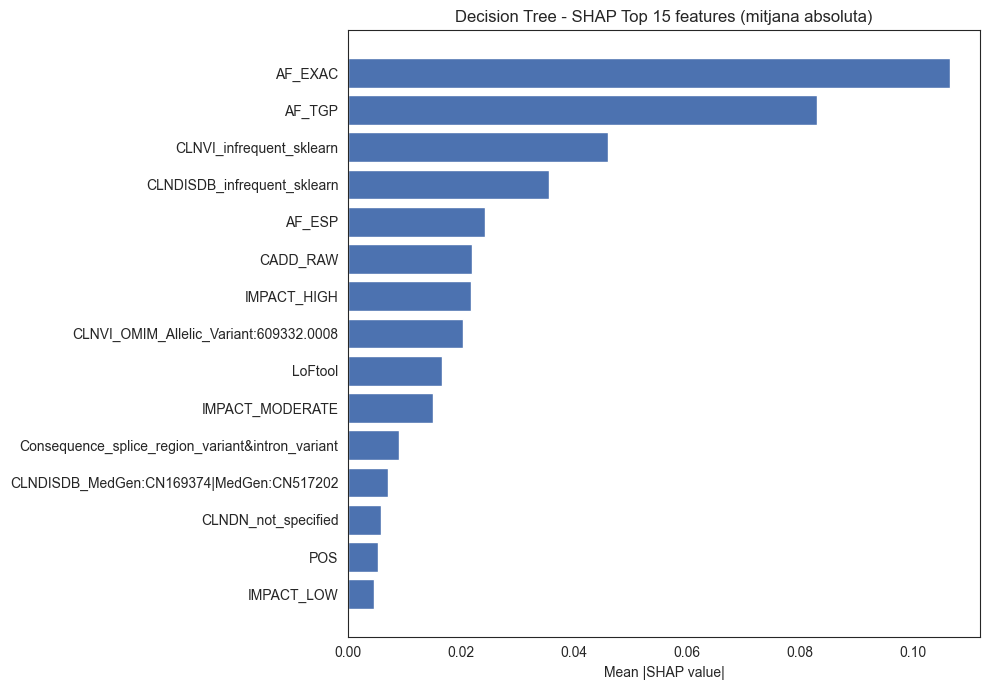

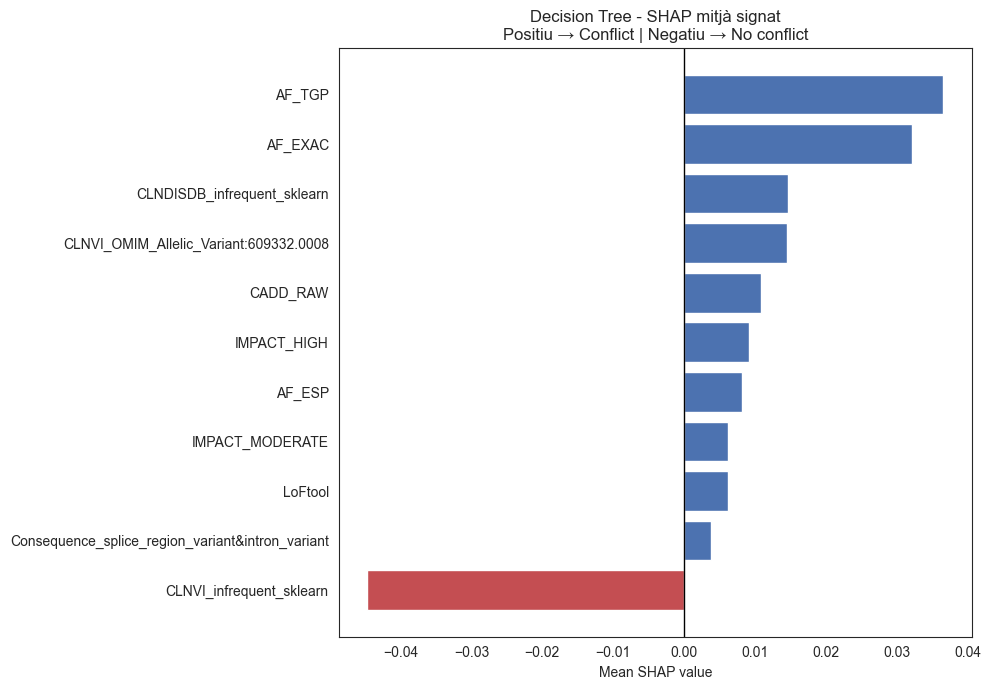

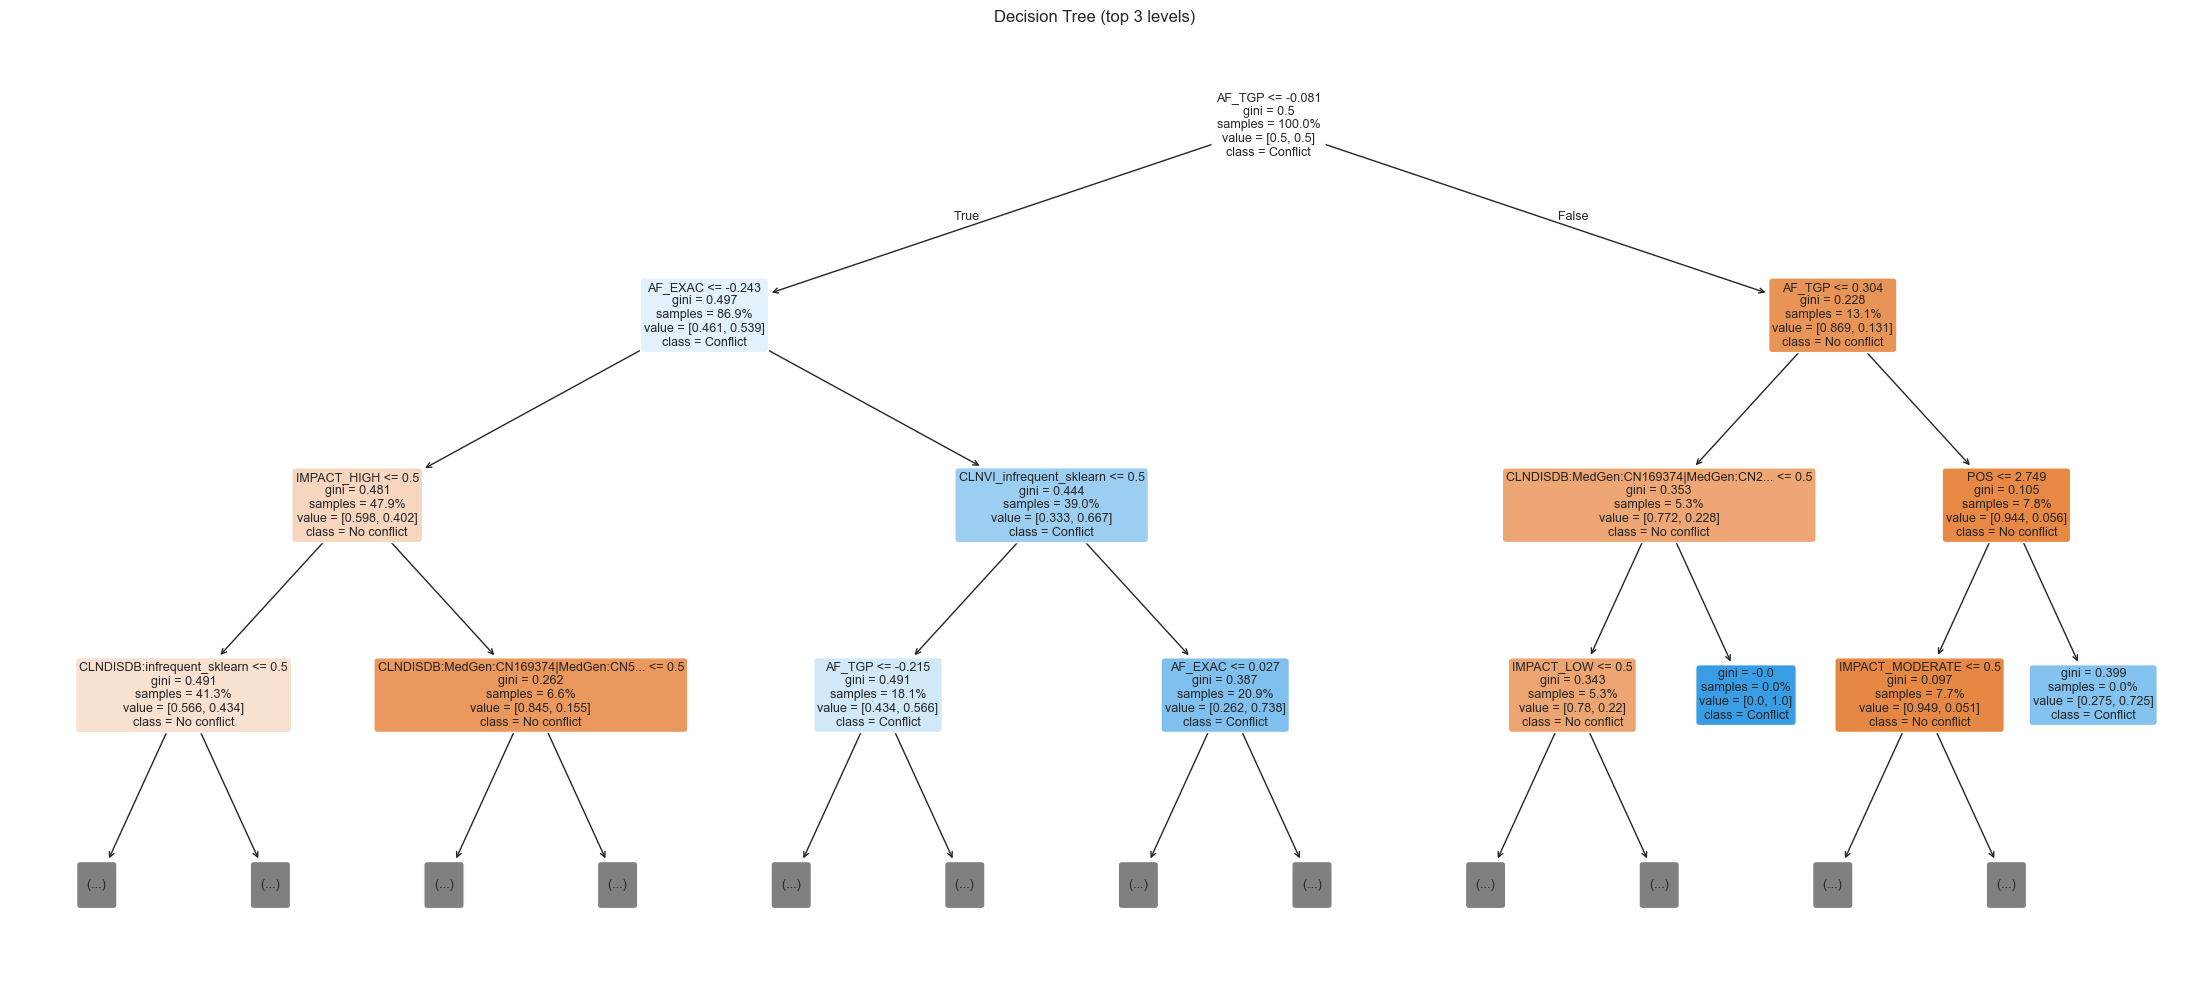

In [25]:
import scipy.sparse
import numpy as np
from sklearn.tree import plot_tree

X_test_transformed_dt = best_model.named_steps["preprocess"].transform(X_test)
if scipy.sparse.issparse(X_test_transformed_dt):
    X_test_transformed_dt = X_test_transformed_dt.toarray().astype(np.float64)
else:
    X_test_transformed_dt = np.array(X_test_transformed_dt, dtype=np.float64)

feature_names_dt = best_model.named_steps["preprocess"].get_feature_names_out()
explainer_dt = shap.TreeExplainer(best_model.named_steps["model"])
shap_values_dt = explainer_dt.shap_values(X_test_transformed_dt)

# Agafem classe 1 (Conflict)
sv_dt = shap_values_dt[1] if isinstance(shap_values_dt, list) else shap_values_dt

# Debug + fix forma
print("Forma shap_values_dt:", np.array(shap_values_dt).shape)
print("Forma sv_dt abans fix:", sv_dt.shape)

# Si és 3D (n_samples, n_features, n_classes) agafem la classe 1
if sv_dt.ndim == 3:
    sv_dt = sv_dt[:, :, 1]

print("Forma sv_dt després fix:", sv_dt.shape)

#  Gràfic 1: Top 15 mitjana absoluta 
mean_abs_dt = np.abs(sv_dt).mean(axis=0)
shap_df_dt = pd.DataFrame({
    "feature": feature_names_dt,
    "mean_abs_shap": mean_abs_dt
}).nlargest(15, "mean_abs_shap").sort_values("mean_abs_shap")

shap_df_dt["feature"] = shap_df_dt["feature"].str.replace("num__", "").str.replace("cat__", "")

plt.figure(figsize=(10, 7))
plt.barh(shap_df_dt["feature"], shap_df_dt["mean_abs_shap"], color="#4C72B0")
plt.title("Decision Tree - SHAP Top 15 features (mitjana absoluta)")
plt.xlabel("Mean |SHAP value|")
plt.tight_layout()
plt.show()

#  Gràfic 2: Positiu i negatiu 
mean_pos_dt = np.where(sv_dt > 0, sv_dt, 0).mean(axis=0)
mean_neg_dt = np.where(sv_dt < 0, sv_dt, 0).mean(axis=0)

shap_full_dt = pd.DataFrame({
    "feature": feature_names_dt,
    "mean_abs_shap": mean_abs_dt,
    "mean_pos_shap": mean_pos_dt,
    "mean_neg_shap": mean_neg_dt
})
shap_full_dt["feature"] = shap_full_dt["feature"].str.replace("num__", "").str.replace("cat__", "")

top_k = 10
top_pos_dt = shap_full_dt.nlargest(top_k, "mean_pos_shap")
top_neg_dt = shap_full_dt.nsmallest(top_k, "mean_neg_shap")

plot_dt = pd.concat([
    top_pos_dt[["feature", "mean_pos_shap"]].rename(columns={"mean_pos_shap": "signed_shap"}),
    top_neg_dt[["feature", "mean_neg_shap"]].rename(columns={"mean_neg_shap": "signed_shap"})
]).drop_duplicates(subset="feature", keep="first").sort_values("signed_shap")

colors = ["#C44E52" if x < 0 else "#4C72B0" for x in plot_dt["signed_shap"]]
plt.figure(figsize=(10, 7))
plt.barh(plot_dt["feature"], plot_dt["signed_shap"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.title("Decision Tree - SHAP mitjà signat\nPositiu → Conflict | Negatiu → No conflict")
plt.xlabel("Mean SHAP value")
plt.tight_layout()
plt.show()

#  plot_tree 
def shorten_feature_name(name, max_len=35):
    name = name.replace("num__", "").replace("cat__", "")
    name = name.replace("CLNDISDB_", "CLNDISDB:").replace("CLNDN_", "CLNDN:")
    return name[:max_len] + "..." if len(name) > max_len else name

feature_names_short = [shorten_feature_name(f) for f in feature_names_dt]
plt.figure(figsize=(22, 10))
plot_tree(
    best_model.named_steps["model"],
    feature_names=feature_names_short,
    class_names=["No conflict", "Conflict"],
    filled=True, rounded=True, max_depth=3,
    fontsize=9, impurity=True, proportion=True
)
plt.title("Decision Tree (top 3 levels)")
plt.tight_layout()
plt.show()

## Interpretació Random Forest (amb SHAP)

Top features més rellevants en valor absolut (RF)


,feature,mean_abs_shap,mean_pos_shap,mean_neg_shap
2,num__AF_EXAC,0.0599,0.0309,-0.0291
3,num__AF_TGP,0.0401,0.0196,-0.0205
914,cat__CLNVI_OMIM_Allelic_Variant:609332.0008,0.0312,0.0157,-0.0156
1,num__AF_ESP,0.0261,0.0128,-0.0134
915,cat__CLNVI_infrequent_sklearn,0.0252,0.0000,-0.0252
906,cat__CLNDN_infrequent_sklearn,0.0160,0.0075,-0.0085
6,num__LoFtool,0.0149,0.0076,-0.0073
491,cat__CLNDISDB_infrequent_sklearn,0.0137,0.0067,-0.0071
8,num__CADD_RAW,0.0132,0.0064,-0.0067
982,cat__IMPACT_HIGH,0.0126,0.0066,-0.0060


Top features positives cap a classe 1 (RF)


,feature,mean_abs_shap,mean_pos_shap,mean_neg_shap
2,num__AF_EXAC,0.0599,0.0309,-0.0291
3,num__AF_TGP,0.0401,0.0196,-0.0205
914,cat__CLNVI_OMIM_Allelic_Variant:609332.0008,0.0312,0.0157,-0.0156
1,num__AF_ESP,0.0261,0.0128,-0.0134
6,num__LoFtool,0.0149,0.0076,-0.0073
906,cat__CLNDN_infrequent_sklearn,0.0160,0.0075,-0.0085
491,cat__CLNDISDB_infrequent_sklearn,0.0137,0.0067,-0.0071
982,cat__IMPACT_HIGH,0.0126,0.0066,-0.0060
8,num__CADD_RAW,0.0132,0.0064,-0.0067
7,num__CADD_PHRED,0.0103,0.0050,-0.0053


Top features negatives cap a classe 0 (RF)


,feature,mean_abs_shap,mean_pos_shap,mean_neg_shap
2,num__AF_EXAC,0.0599,0.0309,-0.0291
915,cat__CLNVI_infrequent_sklearn,0.0252,0.0000,-0.0252
3,num__AF_TGP,0.0401,0.0196,-0.0205
914,cat__CLNVI_OMIM_Allelic_Variant:609332.0008,0.0312,0.0157,-0.0156
1,num__AF_ESP,0.0261,0.0128,-0.0134
906,cat__CLNDN_infrequent_sklearn,0.0160,0.0075,-0.0085
6,num__LoFtool,0.0149,0.0076,-0.0073
491,cat__CLNDISDB_infrequent_sklearn,0.0137,0.0067,-0.0071
8,num__CADD_RAW,0.0132,0.0064,-0.0067
982,cat__IMPACT_HIGH,0.0126,0.0066,-0.0060


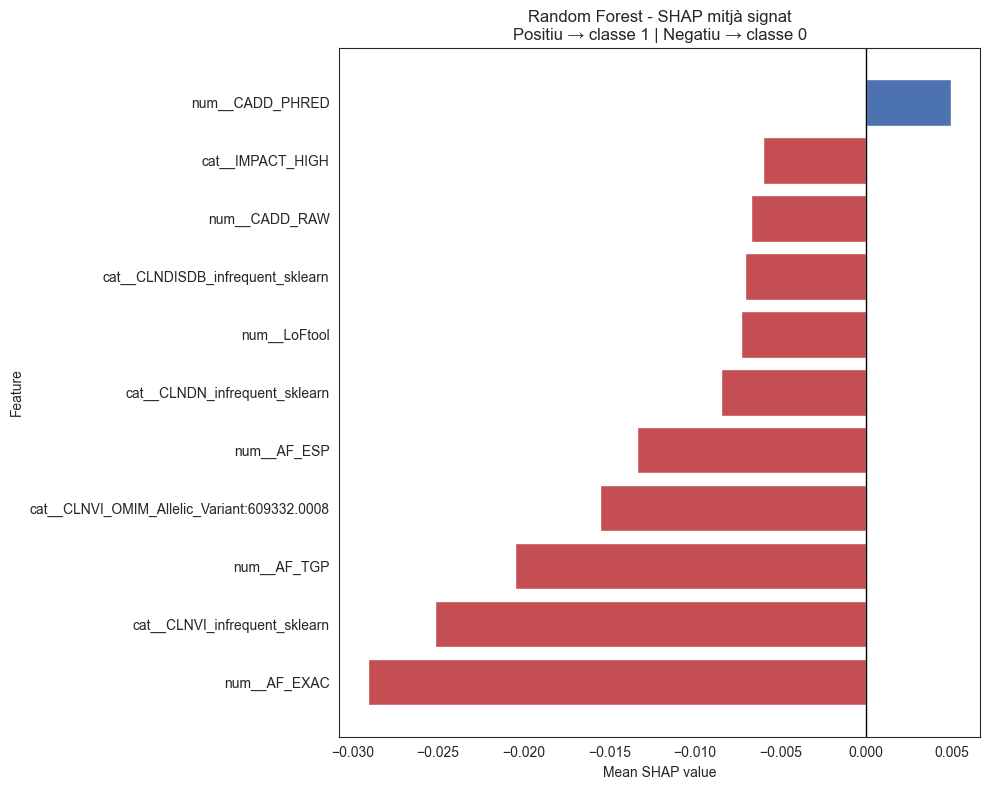

In [26]:
import scipy.sparse
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Transformació
X_test_transformed = best_model_rf_binary.named_steps["preprocess"].transform(X_test)
if scipy.sparse.issparse(X_test_transformed):
    X_test_transformed = X_test_transformed.toarray().astype(np.float64)
else:
    X_test_transformed = np.array(X_test_transformed, dtype=np.float64)

rf_model = best_model_rf_binary.named_steps["model"]
feature_names = best_model_rf_binary.named_steps["preprocess"].get_feature_names_out()

# Test complet
X_shap_sample = X_test_transformed

# SHAP
explainer_rf = shap.TreeExplainer(rf_model)
shap_values_rf = explainer_rf.shap_values(
    X_shap_sample,
    approximate=True,
    check_additivity=False
)

# Adaptar format
if isinstance(shap_values_rf, list):
    sv = shap_values_rf[1]   # classe 1
else:
    sv = shap_values_rf[:, :, 1]

mean_abs_shap = np.abs(sv).mean(axis=0)
mean_pos_shap = np.where(sv > 0, sv, 0).mean(axis=0)
mean_neg_shap = np.where(sv < 0, sv, 0).mean(axis=0)   

rf_shap_df = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": mean_abs_shap,
    "mean_pos_shap": mean_pos_shap,
    "mean_neg_shap": mean_neg_shap
})

# Tops
top_k = 10
top_abs_rf = rf_shap_df.nlargest(top_k, "mean_abs_shap").copy()
top_pos_rf = rf_shap_df.nlargest(top_k, "mean_pos_shap").copy()
top_neg_rf = rf_shap_df.nsmallest(top_k, "mean_neg_shap").copy()

print("Top features més rellevants en valor absolut (RF)")
display(top_abs_rf.round(4))

print("Top features positives cap a classe 1 (RF)")
display(top_pos_rf.round(4))

print("Top features negatives cap a classe 0 (RF)")
display(top_neg_rf.round(4))


plot_rf = pd.concat([
    top_pos_rf.assign(direction="Positive (classe 1)")[["feature", "mean_pos_shap", "direction"]]
        .rename(columns={"mean_pos_shap": "signed_shap"}),
    top_neg_rf.assign(direction="Negative (classe 0)")[["feature", "mean_neg_shap", "direction"]]
        .rename(columns={"mean_neg_shap": "signed_shap"})
], axis=0)

plot_rf = plot_rf.sort_values("signed_shap")
plot_rf = plot_rf.drop_duplicates(subset="feature", keep="first")

plt.figure(figsize=(10, 8))
colors = ["#C44E52" if x < 0 else "#4C72B0" for x in plot_rf["signed_shap"]]

plt.barh(plot_rf["feature"], plot_rf["signed_shap"], color=colors)
plt.axvline(0, color="black", linewidth=1)

plt.title("Random Forest - SHAP mitjà signat\nPositiu → classe 1 | Negatiu → classe 0")
plt.xlabel("Mean SHAP value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Interpretacio MLP (amb SHAP)

/Users/eliag/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/eliag/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/eliag/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sample_weight


X_shap_sample shape: (6519, 4496)


  0%|          | 0/6519 [00:00<?, ?it/s]/Users/eliag/Library/Python/3.9/lib/python/site-packages/shap/explainers/_kernel.py:706: RuntimeWarning: divide by zero encountered in matmul
  w = np.linalg.solve(X.T @ WX, WX.T @ y)
/Users/eliag/Library/Python/3.9/lib/python/site-packages/shap/explainers/_kernel.py:706: RuntimeWarning: overflow encountered in matmul
  w = np.linalg.solve(X.T @ WX, WX.T @ y)
/Users/eliag/Library/Python/3.9/lib/python/site-packages/shap/explainers/_kernel.py:706: RuntimeWarning: invalid value encountered in matmul
  w = np.linalg.solve(X.T @ WX, WX.T @ y)
/Users/eliag/Library/Python/3.9/lib/python/site-packages/shap/explainers/_kernel.py:706: RuntimeWarning: divide by zero encountered in matmul
  w = np.linalg.solve(X.T @ WX, WX.T @ y)
/Users/eliag/Library/Python/3.9/lib/python/site-packages/shap/explainers/_kernel.py:706: RuntimeWarning: overflow encountered in matmul
  w = np.linalg.solve(X.T @ WX, WX.T @ y)
/Users/eliag/Library/Python/3.9/lib/python/site-packa

SHAP values shape: (6519, 4496)
Top features més rellevants en valor absolut (MLP)


,feature,mean_abs_shap,mean_pos_shap,mean_neg_shap
3,num__AF_TGP,0.0216,0.0098,-0.0118
1,num__AF_ESP,0.0154,0.0060,-0.0094
914,cat__CLNVI_OMIM_Allelic_Variant:609332.0008,0.0110,0.0100,-0.0009
8,num__CADD_RAW,0.0088,0.0028,-0.0060
491,cat__CLNDISDB_infrequent_sklearn,0.0040,0.0033,-0.0007
7,num__CADD_PHRED,0.0039,0.0016,-0.0023
2,num__AF_EXAC,0.0037,0.0016,-0.0021
2045,cat__Feature_infrequent_sklearn,0.0037,0.0000,-0.0037
3844,cat__Protein_position_infrequent_sklearn,0.0033,0.0005,-0.0028
906,cat__CLNDN_infrequent_sklearn,0.0031,0.0022,-0.0009


Top features positives cap a classe 1 (MLP)


,feature,mean_abs_shap,mean_pos_shap,mean_neg_shap
914,cat__CLNVI_OMIM_Allelic_Variant:609332.0008,0.0110,0.0100,-0.0009
3,num__AF_TGP,0.0216,0.0098,-0.0118
1,num__AF_ESP,0.0154,0.0060,-0.0094
491,cat__CLNDISDB_infrequent_sklearn,0.0040,0.0033,-0.0007
8,num__CADD_RAW,0.0088,0.0028,-0.0060
906,cat__CLNDN_infrequent_sklearn,0.0031,0.0022,-0.0009
2,num__AF_EXAC,0.0037,0.0016,-0.0021
983,cat__IMPACT_LOW,0.0026,0.0016,-0.0010
7,num__CADD_PHRED,0.0039,0.0016,-0.0023
2803,cat__cDNA_position_infrequent_sklearn,0.0019,0.0013,-0.0006


Top features negatives cap a classe 0 (MLP)


,feature,mean_abs_shap,mean_pos_shap,mean_neg_shap
3,num__AF_TGP,0.0216,0.0098,-0.0118
1,num__AF_ESP,0.0154,0.0060,-0.0094
8,num__CADD_RAW,0.0088,0.0028,-0.0060
2045,cat__Feature_infrequent_sklearn,0.0037,0.0000,-0.0037
3844,cat__Protein_position_infrequent_sklearn,0.0033,0.0005,-0.0028
7,num__CADD_PHRED,0.0039,0.0016,-0.0023
982,cat__IMPACT_HIGH,0.0028,0.0006,-0.0022
2,num__AF_EXAC,0.0037,0.0016,-0.0021
968,cat__Consequence_intron_variant,0.0024,0.0003,-0.0021
1514,cat__SYMBOL_infrequent_sklearn,0.0022,0.0001,-0.0021


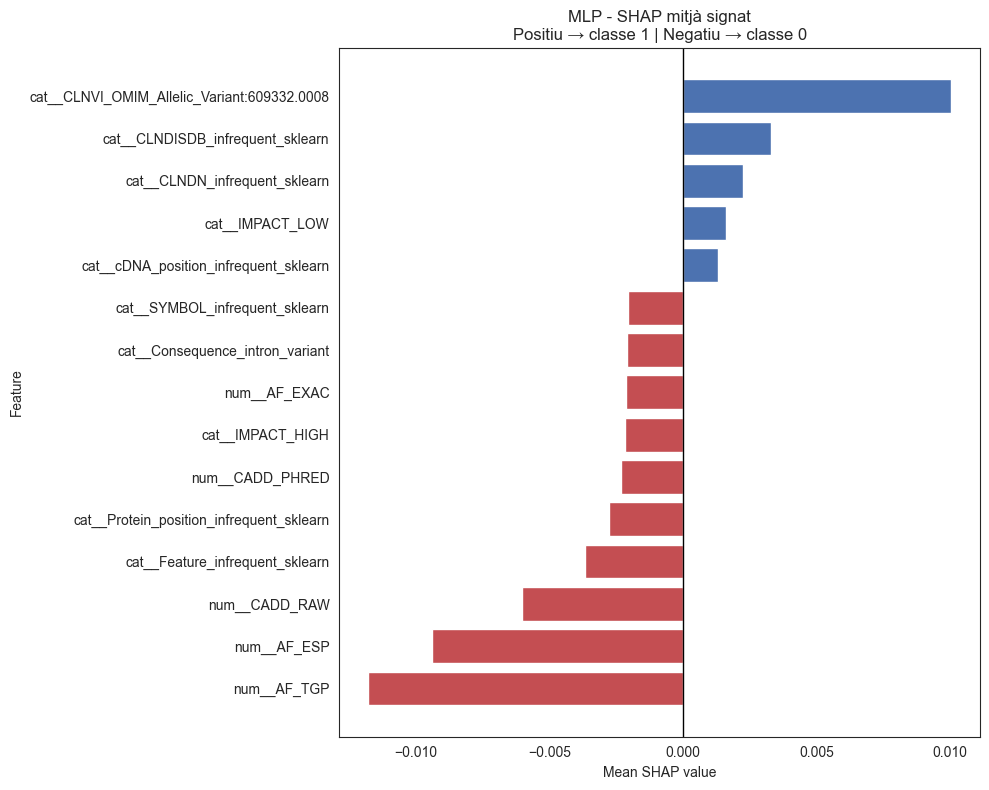

In [27]:
import shap
import scipy.sparse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Transformació
X_test_transformed = best_mlp.named_steps["preprocess"].transform(X_test)
if scipy.sparse.issparse(X_test_transformed):
    X_test_transformed = X_test_transformed.toarray().astype(np.float64)
else:
    X_test_transformed = np.array(X_test_transformed, dtype=np.float64)

X_train_transformed = best_mlp.named_steps["preprocess"].transform(X_train_val)
if scipy.sparse.issparse(X_train_transformed):
    X_train_transformed = X_train_transformed.toarray().astype(np.float64)
else:
    X_train_transformed = np.array(X_train_transformed, dtype=np.float64)

feature_names = best_mlp.named_steps["preprocess"].get_feature_names_out()
mlp_model = best_mlp.named_steps["model"]

# Background reduït des del training
background = shap.kmeans(X_train_transformed, 30)

# Test complet
X_shap_sample = X_test_transformed

print("X_shap_sample shape:", X_shap_sample.shape)

# SHAP
explainer_mlp = shap.KernelExplainer(
    lambda x: mlp_model.predict_proba(x)[:, 1],
    background
)

shap_values_mlp = explainer_mlp.shap_values(X_shap_sample, nsamples=100)
shap_values_mlp = np.array(shap_values_mlp, dtype=np.float64)

print("SHAP values shape:", shap_values_mlp.shape)


mean_abs_shap = np.abs(shap_values_mlp).mean(axis=0)
mean_pos_shap = np.where(shap_values_mlp > 0, shap_values_mlp, 0).mean(axis=0)
mean_neg_shap = np.where(shap_values_mlp < 0, shap_values_mlp, 0).mean(axis=0)

mlp_shap_df = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": mean_abs_shap,
    "mean_pos_shap": mean_pos_shap,
    "mean_neg_shap": mean_neg_shap
})

# Tops
top_k = 10
top_abs_mlp = mlp_shap_df.nlargest(top_k, "mean_abs_shap").copy()
top_pos_mlp = mlp_shap_df.nlargest(top_k, "mean_pos_shap").copy()
top_neg_mlp = mlp_shap_df.nsmallest(top_k, "mean_neg_shap").copy()

print("Top features més rellevants en valor absolut (MLP)")
display(top_abs_mlp.round(4))

print("Top features positives cap a classe 1 (MLP)")
display(top_pos_mlp.round(4))

print("Top features negatives cap a classe 0 (MLP)")
display(top_neg_mlp.round(4))


plot_mlp = pd.concat([
    top_pos_mlp.assign(direction="Positive (classe 1)")[["feature", "mean_pos_shap", "direction"]]
        .rename(columns={"mean_pos_shap": "signed_shap"}),
    top_neg_mlp.assign(direction="Negative (classe 0)")[["feature", "mean_neg_shap", "direction"]]
        .rename(columns={"mean_neg_shap": "signed_shap"})
], axis=0)

plot_mlp = plot_mlp.sort_values("signed_shap")
plot_mlp = plot_mlp.drop_duplicates(subset="feature", keep="first")

plt.figure(figsize=(10, 8))
colors = ["#C44E52" if x < 0 else "#4C72B0" for x in plot_mlp["signed_shap"]]

plt.barh(plot_mlp["feature"], plot_mlp["signed_shap"], color=colors)
plt.axvline(0, color="black", linewidth=1)

plt.title("MLP - SHAP mitjà signat\nPositiu → classe 1 | Negatiu → classe 0")
plt.xlabel("Mean SHAP value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Comparació Intrepretabilitat entre models

Top 15 features més consistents entre tots els models:


,Ridge_L2,Lasso_L1,DT,RF,MLP,mean_across_models,mean_rank
AF_TGP,0.1158,0.1213,0.1596,0.0936,0.0652,0.1111,1.4
AF_ESP,0.0653,0.0549,0.0449,0.0607,0.0462,0.0544,3.2
CLNVI_OMIM_Allelic_Variant:609332.0008,0.0452,0.0523,0.0428,0.0673,0.0310,0.0477,3.8
CLNDISDB_infrequent_sklearn,0.0223,0.0322,0.0782,0.0293,0.0128,0.0350,5.6
CADD_RAW,0.0191,0.0140,0.0495,0.0291,0.0272,0.0278,7.6
IMPACT_HIGH,0.0167,0.0174,0.0425,0.0327,0.0084,0.0236,9.2
AF_EXAC,0.0086,0.0068,0.2316,0.1243,0.0117,0.0766,10.8
CLNDN_infrequent_sklearn,0.0229,0.0129,0.0053,0.0343,0.0100,0.0171,11.4
LoFtool,0.0201,0.0207,0.0360,0.0312,0.0057,0.0227,12.2
Feature_infrequent_sklearn,0.0119,0.0095,0.0039,0.0048,0.0127,0.0085,17.0


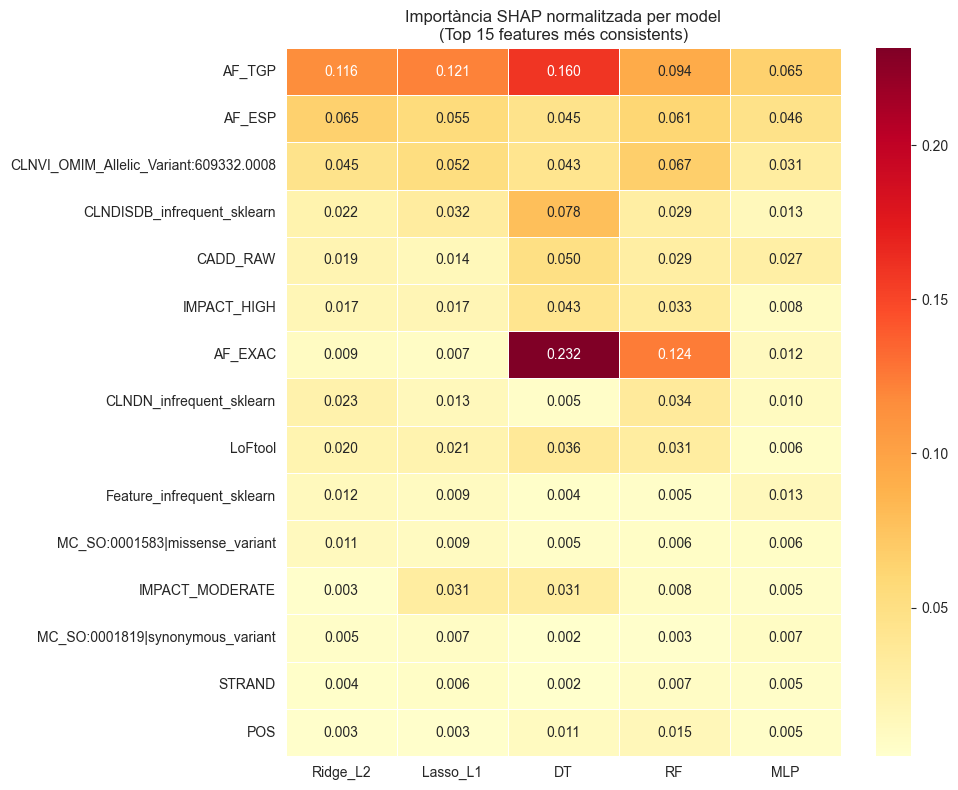

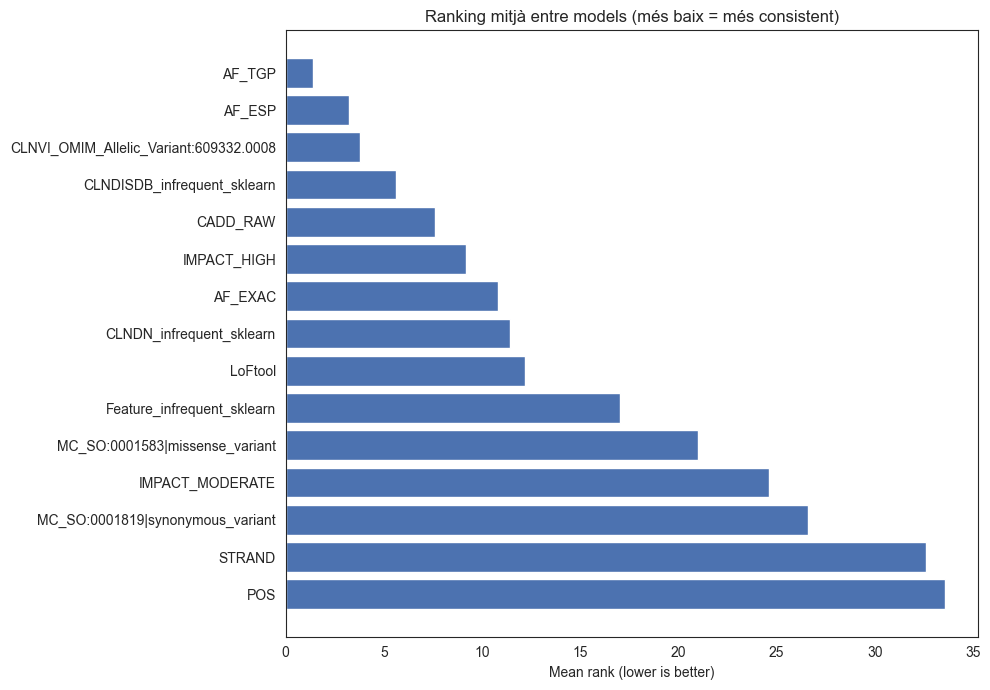

In [28]:
# Ridge / Lasso → LinearExplainer retorna 2D directament (classe 1)
sv_l2 = shap_values_l2 if not isinstance(shap_values_l2, list) else shap_values_l2[1]
sv_l1 = shap_values_l1 if not isinstance(shap_values_l1, list) else shap_values_l1[1]

# RF → pot ser llista o array 3D
if isinstance(shap_values_rf, list):
    sv_rf = shap_values_rf[1]
else:
    sv_rf = shap_values_rf[:, :, 1] if shap_values_rf.ndim == 3 else shap_values_rf

# MLP → KernelExplainer retorna 2D per classificació binària
sv_mlp = shap_values_mlp if shap_values_mlp.ndim == 2 else shap_values_mlp[:, :, 1]

# feature_names compartit per L2, L1, RF, MLP (mateixa pipeline de preprocessat)
feature_names_rf  = feature_names
feature_names_mlp = feature_names


def get_normalized_shap(sv, feature_names):

    abs_sv = np.abs(sv)
    total_per_sample = abs_sv.sum(axis=1, keepdims=True)
    total_per_sample = np.where(total_per_sample == 0, 1, total_per_sample)
    normalized = abs_sv / total_per_sample
    mean_normalized = normalized.mean(axis=0)

    clean_names = [f.replace("num__", "").replace("cat__", "") for f in feature_names]

    return pd.Series(mean_normalized, index=clean_names)


# Calcular per cada model
importance_l2  = get_normalized_shap(sv_l2,  feature_names)
importance_l1  = get_normalized_shap(sv_l1,  feature_names)
importance_dt  = get_normalized_shap(sv_dt,  feature_names_dt)
importance_rf  = get_normalized_shap(sv_rf,  feature_names_rf)
importance_mlp = get_normalized_shap(sv_mlp, feature_names_mlp)

# Ajuntar tot en un DataFrame
meta_df = pd.DataFrame({
    "Ridge_L2":  importance_l2,
    "Lasso_L1":  importance_l1,
    "DT":        importance_dt,
    "RF":        importance_rf,
    "MLP":       importance_mlp,
}).fillna(0)

# Mitjana entre models → importància global
meta_df["mean_across_models"] = meta_df.mean(axis=1)

# Ranking per cada model
for col in ["Ridge_L2", "Lasso_L1", "DT", "RF", "MLP"]:
    meta_df[f"rank_{col}"] = meta_df[col].rank(ascending=False).astype(int)

meta_df["mean_rank"] = meta_df[["rank_Ridge_L2", "rank_Lasso_L1", "rank_DT", "rank_RF", "rank_MLP"]].mean(axis=1)

# Top 15 features més consistents entre models
top15 = meta_df.sort_values("mean_rank").head(15)

print("Top 15 features més consistents entre tots els models:")
display(top15[["Ridge_L2", "Lasso_L1", "DT", "RF", "MLP", "mean_across_models", "mean_rank"]].round(4))


# Gràfic 1: Heatmap de importàncies normalitzades 
top15_heat = top15[["Ridge_L2", "Lasso_L1", "DT", "RF", "MLP"]]

plt.figure(figsize=(10, 8))
sns.heatmap(
    top15_heat,
    annot=True, fmt=".3f",
    cmap="YlOrRd",
    linewidths=0.5
)
plt.title("Importància SHAP normalitzada per model\n(Top 15 features més consistents)")
plt.tight_layout()
plt.show()


# Gràfic 2: Ranking mitjà (quant més baix, més consistent) 
top15_rank = meta_df.sort_values("mean_rank").head(15).copy()
top15_rank["feature"] = top15_rank.index

plt.figure(figsize=(10, 7))
plt.barh(
    top15_rank["feature"][::-1],
    top15_rank["mean_rank"][::-1],
    color="#4C72B0"
)
plt.title("Ranking mitjà entre models (més baix = més consistent)")
plt.xlabel("Mean rank (lower is better)")
plt.tight_layout()
plt.show()


## CLASS – Dataset Bàsic (sense anotació VEP)

In [29]:
# Crear dataset bàsic (sense columnes VEP)
vep_cols = [
    "Allele", "Consequence", "IMPACT", "SYMBOL", "Feature_type", "Feature",
    "BIOTYPE", "EXON", "INTRON", "cDNA_position", "CDS_position",
    "Protein_position", "Amino_acids", "Codons", "STRAND", "BAM_EDIT",
    "SIFT", "PolyPhen", "LoFtool", "CADD_PHRED", "CADD_RAW", "BLOSUM62"
]

df_basic = df.drop(columns=[c for c in vep_cols if c in df.columns])
df_basic.to_csv("../data/raw/clinvar_class_basic.csv", index=False)

print("Annotated shape:", df.shape)
print("Basic shape:    ", df_basic.shape)
print("Columnes eliminades:", [c for c in vep_cols if c in df.columns])

Annotated shape: (65188, 46)
Basic shape:     (65188, 24)
Columnes eliminades: ['Allele', 'Consequence', 'IMPACT', 'SYMBOL', 'Feature_type', 'Feature', 'BIOTYPE', 'EXON', 'INTRON', 'cDNA_position', 'CDS_position', 'Protein_position', 'Amino_acids', 'Codons', 'STRAND', 'BAM_EDIT', 'SIFT', 'PolyPhen', 'LoFtool', 'CADD_PHRED', 'CADD_RAW', 'BLOSUM62']


## Partició de dades i Preprocessat (Bàsic)

In [30]:
TARGET_COL = "CLASS"
RANDOM_STATE = 42
TEST_SIZE = 0.10

X_b = df_basic.drop(columns=[TARGET_COL])
y_b = df_basic[TARGET_COL]

X_train_val_basic, X_test_basic, y_train_val_basic, y_test_basic = train_test_split(
    X_b, y_b,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_b,
)

cols_high_missing = [
    'MOTIF_SCORE_CHANGE', 'HIGH_INF_POS', 'MOTIF_POS', 'MOTIF_NAME',
    'DISTANCE', 'SSR', 'CLNSIGINCL', 'CLNDISDBINCL', 'CLNDNINCL'
]
X_train_val_basic = X_train_val_basic.drop(columns=cols_high_missing, errors="ignore")
X_test_basic      = X_test_basic.drop(columns=cols_high_missing, errors="ignore")

num_cols_b = X_train_val_basic.select_dtypes(include=np.number).columns.tolist()
cat_cols_b = X_train_val_basic.select_dtypes(exclude=np.number).columns.tolist()

numeric_transformer_b = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_transformer_b = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=20)),
])
preprocessor_basic = ColumnTransformer(transformers=[
    ("num", numeric_transformer_b, num_cols_b),
    ("cat", categorical_transformer_b, cat_cols_b),
])

print("X_train_val_basic shape:", X_train_val_basic.shape)
print("X_test_basic shape:", X_test_basic.shape)

X_train_val_basic shape: (58669, 14)
X_test_basic shape: (6519, 14)


## SVM (Bàsic)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Millors paràmetres: {'model__C': 0.01, 'model__class_weight': None}
Millor CV ROC AUC: 0.739748211321012
Test ROC AUC: 0.7372656238687809


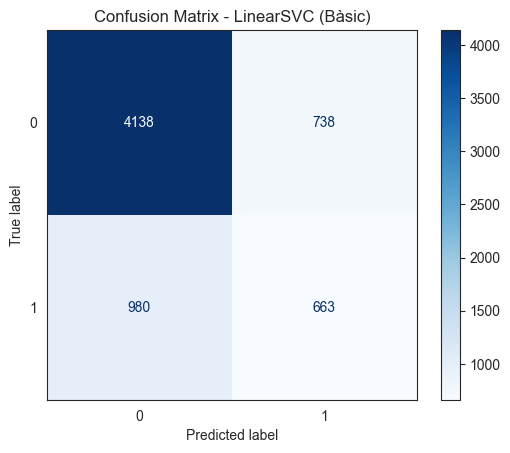

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

linear_svm_b = LinearSVC(
    random_state=42,
    max_iter=100000,
    dual=False,
    loss="squared_hinge"
)

pipeline_linsvm_basic = Pipeline(steps=[
    ("preprocess", preprocessor_basic),
    ("model", linear_svm_b)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1.0, 10.0],
    "model__class_weight": [None, "balanced"]
}

grid_svm_basic = GridSearchCV(
    estimator=pipeline_linsvm_basic,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)
grid_svm_basic.fit(X_train_val_basic, y_train_val_basic)

print("Millors paràmetres:", grid_svm_basic.best_params_)
print("Millor CV ROC AUC:", grid_svm_basic.best_score_)

best_svm_basic = grid_svm_basic.best_estimator_
svm_scores_basic = best_svm_basic.decision_function(X_test_basic)
y_pred_svm_basic = best_svm_basic.predict(X_test_basic)
auc_svm_basic = roc_auc_score(y_test_basic, svm_scores_basic)
cm_svm_basic = confusion_matrix(y_test_basic, y_pred_svm_basic)

print("Test ROC AUC:", auc_svm_basic)
ConfusionMatrixDisplay(confusion_matrix=cm_svm_basic).plot(cmap="Blues")
plt.title("Confusion Matrix - LinearSVC (Bàsic)")
plt.show()

## MLP (Bàsic)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Millors paràmetres: {'model__alpha': 0.001, 'model__hidden_layer_sizes': (64,), 'model__learning_rate_init': 0.001}
Millor CV ROC AUC: 0.7656743053670968
Test ROC AUC: 0.7569764861193011


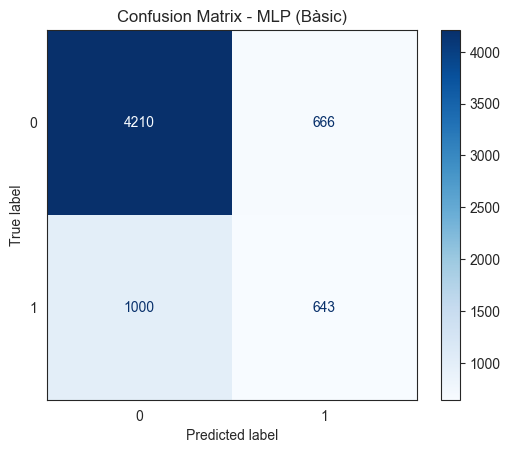

In [32]:
warnings.filterwarnings("ignore", category=RuntimeWarning, module=r"sklearn\.utils\.extmath")

mlp_b = MLPClassifier(
    activation="relu",
    solver="adam",
    hidden_layer_sizes=(128,),
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    tol=1e-4,
    max_iter=300,
    random_state=42
)

pipeline_mlp_basic = Pipeline(steps=[
    ("preprocess", preprocessor_basic),
    ("model", mlp_b)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid_mlp_b = {
    "model__hidden_layer_sizes": [(64,), (128,), (64, 32)],
    "model__alpha":              [1e-3, 5e-3],
    "model__learning_rate_init": [1e-4, 5e-4, 1e-3],
}

grid_mlp_basic = GridSearchCV(
    pipeline_mlp_basic,
    param_grid=param_grid_mlp_b,
    scoring="roc_auc",
    cv=cv,
    n_jobs=1,
    verbose=1,
    error_score="raise"
)
grid_mlp_basic.fit(X_train_val_basic, y_train_val_basic)

print("Millors paràmetres:", grid_mlp_basic.best_params_)
print("Millor CV ROC AUC:", grid_mlp_basic.best_score_)

best_mlp_basic = grid_mlp_basic.best_estimator_
mlp_proba_basic = best_mlp_basic.predict_proba(X_test_basic)[:, 1]
y_pred_mlp_basic = best_mlp_basic.predict(X_test_basic)
auc_mlp_basic = roc_auc_score(y_test_basic, mlp_proba_basic)
cm_mlp_basic = confusion_matrix(y_test_basic, y_pred_mlp_basic)

print("Test ROC AUC:", auc_mlp_basic)
ConfusionMatrixDisplay(confusion_matrix=cm_mlp_basic).plot(cmap="Blues")
plt.title("Confusion Matrix - MLP (Bàsic)")
plt.show()

## Ridge logistic regression (Bàsic)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Millors paràmetres: {'model__C': 0.1, 'model__class_weight': None}
Millor CV ROC AUC: 0.7458895387986557
Test ROC AUC: 0.7431528317364992


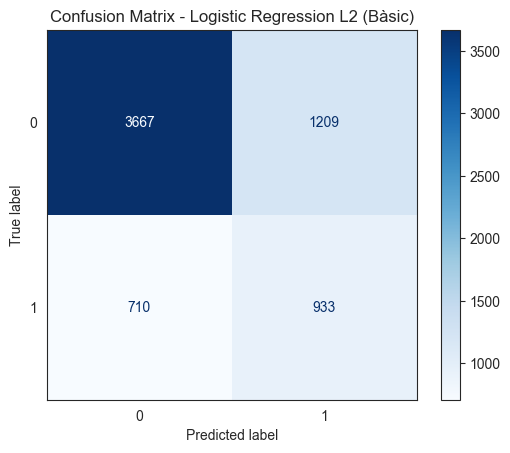

In [33]:
logreg_l2_b = LogisticRegression(
    penalty="l2",
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

pipeline_logreg_l2_basic = Pipeline(steps=[
    ("preprocess", preprocessor_basic),
    ("model", logreg_l2_b)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1.0, 10.0],
    "model__class_weight": [None, "balanced"]
}

grid_l2_basic = GridSearchCV(
    estimator=pipeline_logreg_l2_basic,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)
grid_l2_basic.fit(X_train_val_basic, y_train_val_basic)

print("Millors paràmetres:", grid_l2_basic.best_params_)
print("Millor CV ROC AUC:", grid_l2_basic.best_score_)

best_l2_basic = grid_l2_basic.best_estimator_
l2_proba_basic = best_l2_basic.predict_proba(X_test_basic)[:, 1]
y_pred_l2_basic = best_l2_basic.predict(X_test_basic)
auc_l2_basic = roc_auc_score(y_test_basic, l2_proba_basic)
cm_l2_basic = confusion_matrix(y_test_basic, y_pred_l2_basic)

print("Test ROC AUC:", auc_l2_basic)
ConfusionMatrixDisplay(confusion_matrix=cm_l2_basic).plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression L2 (Bàsic)")
plt.show()

## Lasso logistic regression (Bàsic)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Millors paràmetres: {'model__C': 1.0, 'model__class_weight': None}
Millor CV ROC AUC: 0.7440386642555088
Test ROC AUC: 0.7425264639754905


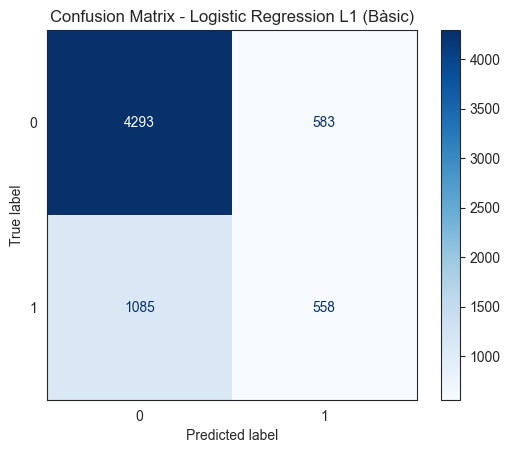

In [34]:
logreg_l1_b = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

pipeline_logreg_l1_basic = Pipeline(steps=[
    ("preprocess", preprocessor_basic),
    ("model", logreg_l1_b)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1.0, 10.0],
    "model__class_weight": [None, "balanced"]
}

grid_l1_basic = GridSearchCV(
    estimator=pipeline_logreg_l1_basic,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)
grid_l1_basic.fit(X_train_val_basic, y_train_val_basic)

print("Millors paràmetres:", grid_l1_basic.best_params_)
print("Millor CV ROC AUC:", grid_l1_basic.best_score_)

best_l1_basic = grid_l1_basic.best_estimator_
l1_proba_basic = best_l1_basic.predict_proba(X_test_basic)[:, 1]
y_pred_l1_basic = best_l1_basic.predict(X_test_basic)
auc_l1_basic = roc_auc_score(y_test_basic, l1_proba_basic)
cm_l1_basic = confusion_matrix(y_test_basic, y_pred_l1_basic)

print("Test ROC AUC:", auc_l1_basic)
ConfusionMatrixDisplay(confusion_matrix=cm_l1_basic).plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression L1 (Bàsic)")
plt.show()

## Decision Tree (Bàsic)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Millors paràmetres: {'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__min_samples_leaf': 10, 'model__min_samples_split': 2}
Millor CV ROC AUC: 0.7432848294217589
Test ROC AUC: 0.7107560875506849


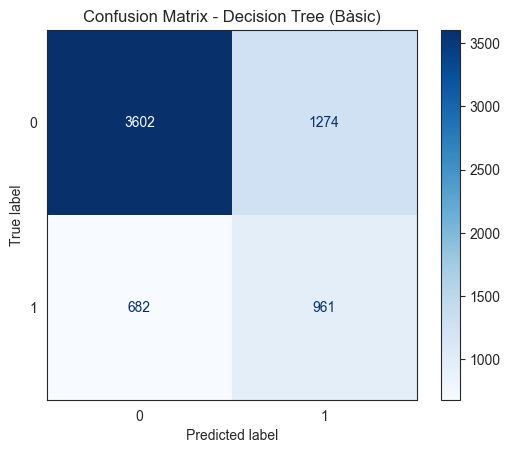

In [35]:
from sklearn.tree import DecisionTreeClassifier

dt_b = DecisionTreeClassifier(
    random_state=42
)

pipeline_dt_binary_basic = Pipeline(steps=[
    ("preprocess", preprocessor_basic),
    ("model", dt_b)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid_dt_b = {
    "model__max_depth":         [5, 10, 20, None],
    "model__min_samples_split": [2, 10, 20],
    "model__min_samples_leaf":  [1, 5, 10],
    "model__class_weight":      [None, "balanced"]
}

grid_dt_binary_basic = GridSearchCV(
    estimator=pipeline_dt_binary_basic,
    param_grid=param_grid_dt_b,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)
grid_dt_binary_basic.fit(X_train_val_basic, y_train_val_basic)

print("Millors paràmetres:", grid_dt_binary_basic.best_params_)
print("Millor CV ROC AUC:", grid_dt_binary_basic.best_score_)

best_dt_basic = grid_dt_binary_basic.best_estimator_
dt_proba_basic = best_dt_basic.predict_proba(X_test_basic)[:, 1]
y_pred_dt_basic = best_dt_basic.predict(X_test_basic)
auc_dt_basic = roc_auc_score(y_test_basic, dt_proba_basic)
cm_dt_basic = confusion_matrix(y_test_basic, y_pred_dt_basic)

print("Test ROC AUC:", auc_dt_basic)
ConfusionMatrixDisplay(confusion_matrix=cm_dt_basic).plot(cmap="Blues")
plt.title("Confusion Matrix - Decision Tree (Bàsic)")
plt.show()

## Random Forest (Bàsic)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Millors paràmetres: {'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 0.3, 'model__max_depth': 20, 'model__class_weight': None}
Millor CV ROC AUC: 0.7912970874064428
Test ROC AUC: 0.7993221547450418


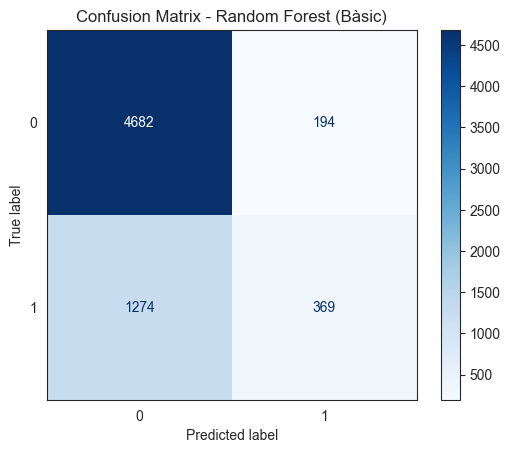

In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_score


rf_b = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

pipeline_rf_binary_basic = Pipeline(steps=[
    ("preprocess", preprocessor_basic),
    ("model", rf_b)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_dist_rf_b = {
    "model__n_estimators":      [100, 200, 300],
    "model__max_depth":         [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf":  [1, 2, 5],
    "model__max_features":      ["sqrt", 0.3],
    "model__class_weight":      [None, "balanced"]
}

random_search_rf_binary_basic = RandomizedSearchCV(
    estimator=pipeline_rf_binary_basic,
    param_distributions=param_dist_rf_b,
    n_iter=10,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42,
    refit=True
)
random_search_rf_binary_basic.fit(X_train_val_basic, y_train_val_basic)

print("Millors paràmetres:", random_search_rf_binary_basic.best_params_)
print("Millor CV ROC AUC:", random_search_rf_binary_basic.best_score_)

best_rf_basic = random_search_rf_binary_basic.best_estimator_
rf_proba_basic = best_rf_basic.predict_proba(X_test_basic)[:, 1]
y_pred_rf_basic = best_rf_basic.predict(X_test_basic)
auc_rf_basic = roc_auc_score(y_test_basic, rf_proba_basic)
cm_rf_basic = confusion_matrix(y_test_basic, y_pred_rf_basic)

print("Test ROC AUC:", auc_rf_basic)
ConfusionMatrixDisplay(confusion_matrix=cm_rf_basic).plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest (Bàsic)")
plt.show()

## Corbes ROC AUC al conjunt de test (Bàsic)

La imatge mostra les corbes ROC dels sis models avaluats sobre el conjunt de test amb el conjunt de features bàsiques: LinearSVC, MLP, Logistic Regression L2, Logistic Regression L1, Decision Tree i Random Forest. Tots es comparen respecte al classificador aleatori per valorar la seva capacitat discriminativa.
La comparació visual de les corbes i dels valors AUC permet identificar quin model manté el millor equilibri entre sensibilitat i especificitat en el conjunt de test bàsic.
Aquesta figura resumeix el rendiment relatiu de tots els models binaris entrenats amb features bàsiques.

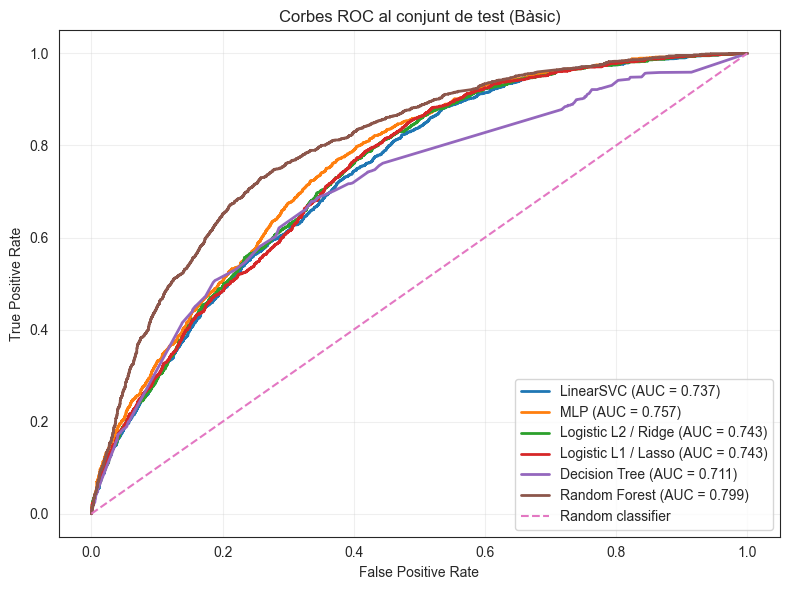

In [38]:
from sklearn.metrics import roc_curve, roc_auc_score

# --- ROC curve points ---
fpr_svm_b, tpr_svm_b, _ = roc_curve(y_test_basic, svm_scores_basic)
fpr_mlp_b, tpr_mlp_b, _ = roc_curve(y_test_basic, mlp_proba_basic)
fpr_l2_b,  tpr_l2_b,  _ = roc_curve(y_test_basic, l2_proba_basic)
fpr_l1_b,  tpr_l1_b,  _ = roc_curve(y_test_basic, l1_proba_basic)
fpr_dt_b,  tpr_dt_b,  _ = roc_curve(y_test_basic, dt_proba_basic)
fpr_rf_b,  tpr_rf_b,  _ = roc_curve(y_test_basic, rf_proba_basic)

# --- Plot ---
plt.figure(figsize=(8, 6))

plt.plot(fpr_svm_b, tpr_svm_b, linewidth=2, label=f"LinearSVC (AUC = {auc_svm_basic:.3f})")
plt.plot(fpr_mlp_b, tpr_mlp_b, linewidth=2, label=f"MLP (AUC = {auc_mlp_basic:.3f})")
plt.plot(fpr_l2_b,  tpr_l2_b,  linewidth=2, label=f"Logistic L2 / Ridge (AUC = {auc_l2_basic:.3f})")
plt.plot(fpr_l1_b,  tpr_l1_b,  linewidth=2, label=f"Logistic L1 / Lasso (AUC = {auc_l1_basic:.3f})")
plt.plot(fpr_dt_b,  tpr_dt_b,  linewidth=2, label=f"Decision Tree (AUC = {auc_dt_basic:.3f})")
plt.plot(fpr_rf_b,  tpr_rf_b,  linewidth=2, label=f"Random Forest (AUC = {auc_rf_basic:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Corbes ROC al conjunt de test (Bàsic)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Comparació Models – Annotated vs Bàsic

,Model,Dataset,CV AUC,Test AUC
0,LinearSVC,Annotated,0.7418,0.7431
1,MLP,Annotated,0.7595,0.7633
2,Logistic L2,Annotated,0.7488,0.7493
3,Logistic L1,Annotated,0.7429,0.7474
4,Decision Tree,Annotated,0.7579,0.7196
5,Random Forest,Annotated,0.8140,0.8269
6,LinearSVC,Basic,0.7397,0.7373
7,MLP,Basic,0.7657,0.7570
8,Logistic L2,Basic,0.7459,0.7432
9,Logistic L1,Basic,0.7440,0.7425


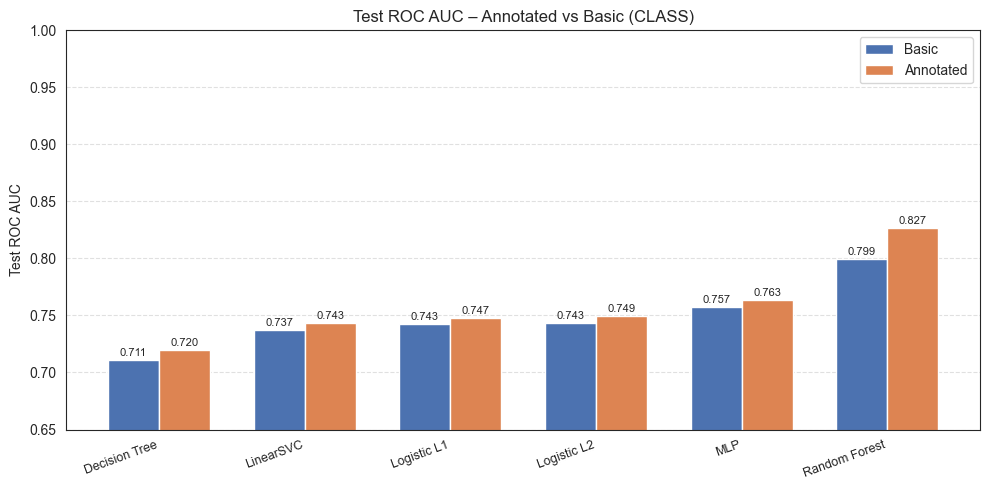

In [37]:
models_comparison = [
    ("LinearSVC",     "Annotated", grid_svm.best_score_,                auc_svm),
    ("MLP",           "Annotated", grid_mlp.best_score_,                auc_mlp),
    ("Logistic L2",   "Annotated", grid_l2.best_score_,                 auc_l2),
    ("Logistic L1",   "Annotated", grid_l1.best_score_,                 auc_l1),
    ("Decision Tree", "Annotated", grid_dt_binary.best_score_,          auc_dt_binary),
    ("Random Forest", "Annotated", random_search_rf_binary.best_score_, auc_rf_binary),
    ("LinearSVC",     "Basic",     grid_svm_basic.best_score_,                auc_svm_basic),
    ("MLP",           "Basic",     grid_mlp_basic.best_score_,                auc_mlp_basic),
    ("Logistic L2",   "Basic",     grid_l2_basic.best_score_,                 auc_l2_basic),
    ("Logistic L1",   "Basic",     grid_l1_basic.best_score_,                 auc_l1_basic),
    ("Decision Tree", "Basic",     grid_dt_binary_basic.best_score_,          auc_dt_basic),
    ("Random Forest", "Basic",     random_search_rf_binary_basic.best_score_,  auc_rf_basic),
]

df_comp = pd.DataFrame(models_comparison, columns=["Model", "Dataset", "CV AUC", "Test AUC"])
df_comp["CV AUC"]   = df_comp["CV AUC"].round(4)
df_comp["Test AUC"] = df_comp["Test AUC"].round(4)
display(df_comp)

pivot = df_comp.pivot(index="Model", columns="Dataset", values="Test AUC")

model_names = pivot.index.tolist()
x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, pivot["Basic"],     width, label="Basic",     color="#4C72B0")
ax.bar(x + width/2, pivot["Annotated"], width, label="Annotated", color="#DD8452")

for i, (b, a) in enumerate(zip(pivot["Basic"], pivot["Annotated"])):
    ax.text(i - width/2, b + 0.002, f"{b:.3f}", ha="center", va="bottom", fontsize=8)
    ax.text(i + width/2, a + 0.002, f"{a:.3f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=20, ha="right", fontsize=9)
ax.set_ylim(0.65, 1.00)
ax.set_ylabel("Test ROC AUC")
ax.set_title("Test ROC AUC – Annotated vs Basic (CLASS)")
ax.legend()
ax.yaxis.grid(True, linestyle="--", alpha=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()